In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install pymanopt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.0 MB/s eta 0:00:00


In [ ]:
import pymanopt
from pymanopt.manifolds.manifold import Manifold
from pymanopt import function
import numpy as np
from scipy.linalg import expm
from scipy.stats import special_ortho_group
from pymanopt.optimizers import SteepestDescent
from pymanopt.optimizers import TrustRegions
import matplotlib.pyplot as plt
from pymanopt.tools.diagnostics import check_gradient, check_hessian
from pymanopt import Problem, optimizers
from pymanopt.optimizers.optimizer import OptimizerResult
import time

from pymanopt.function import numpy as pymanopt_function
import matplotlib.pyplot as plt

class SpecialOrthogonalProductAnchored(Manifold):
    def __init__(self, d, m, anchor_indices, anchor_values,E,H,kappa1=1.0, kappa2=0.1, q=0.9):
        self._d = d
        self._m = m
        self._H=H
        self._E=E
        self._anchors = anchor_indices
        self._anchor_values = anchor_values
        self._non_anchors = [i for i in range(m) if i not in anchor_indices]
        self._triu_indices = np.triu_indices(d, k=1)
        self._tangent_dim = d*(d-1)//2
        self._kappa1=kappa1
        self._kappa2=kappa2
        self._q=q

        # Dimension is (m - |anchors|) * dim(SO(d))
        dim_SO = d * (d - 1) // 2
        self._dimension = (m - len(anchor_indices)) * dim_SO
        self._name = "SpecialOrthogonalProductAnchored"

        super().__init__("Anchored SO(d)^m", self._dimension)

        self._c1 = np.exp(-d*kappa1) * self._compute_cd(kappa1)
        self._c2 = np.exp(-d*kappa2) * self._compute_cd(kappa2)

    def inner_product(self, X, Omega, Psi):
        ip = 0.0
        for i in self._non_anchors:
            ip += 2.0 * np.dot(Omega[i].T, Psi[i])
        return ip

    def norm(self,X, Omega):
        return np.sqrt(self.inner_product(X, Omega, Omega))

    def _unskew(self, omega_flat):
        """Convert compressed tangent vector to full skew-symmetric matrix."""
        Omega = np.zeros((self._d, self._d))
        Omega[self._triu_indices] = omega_flat
        Omega.T[self._triu_indices] = -omega_flat
        return Omega

    def to_tangent_space(self, X, Z):
        P = np.zeros((self._m, self._tangent_dim))
        for i in self._non_anchors:
            # Compute skew-symmetric part of XᵢᵀZᵢ
            skew_part = 0.5 * (X[i].T @ Z[i] - Z[i].T @ X[i])

            # Extract upper triangular elements (k=1 excludes diagonal)
            P[i] = skew_part
        return P

    def _skew(self, Omega):
        """Extract upper triangular elements from skew-symmetric matrix."""
        return Omega[self._triu_indices]


    @property
    def typical_dist(self):
        return 1

    def projection(self, X, Z):
        """Project ambient vector Z to tangent space, returning compressed skew-symmetric vectors."""
        P = np.zeros((self._m, self._tangent_dim))  # Allocate space for compressed vectors

        for i in self._non_anchors:
            # Compute skew-symmetric part of XᵢᵀZᵢ
            skew_part = 0.5 * (X[i].T @ Z[i] - Z[i].T @ X[i])

            # Extract upper triangular elements (k=1 excludes diagonal)
            P[i] = skew_part[self._triu_indices]

        return P



    def dim(self):
        return self._dimension

    def euclidean_to_riemannian_gradient(self, x, egrad):
        return self.projection(x,egrad)



    def retraction(self, X, Omega):
        R = np.zeros_like(X)
        for i in range(self._m):
            if i in self._anchors:
                R[i] = X[i]  # Anchored points don't move
            else:
                Omega_i = self._unskew(Omega[i])
                R[i] = X[i] @ expm(Omega_i)
        return R

    def random_point(self):
        X = np.zeros((self._m, self._d, self._d))
        for i in range(self._m):
            if i in self._anchors:
                X[i] = self._anchor_values[i]
            else:
                X[i] = special_ortho_group.rvs(self._d)
        return X

    def random_tangent_vector(self, X):
        return self.projection(X,self.random_point())

    def zero_vector(self, X):
        return np.zeros((self._m, self._d))

    def _compute_cd(self, kappa):
        """Compute the normalizing constant c_d(kappa) for SO(d) Langevin distribution"""
        if kappa == 0:
            return 1.0  # Uniform distribution case
        if self._d == 2:
            return 2 * np.pi * iv(0, kappa)
        elif self._d == 3:
            return 4 * np.pi * (np.sinh(kappa) / kappa)
        else:
            # For higher dimensions, we'd need a more general approach
            raise NotImplementedError("Normalizing constant only implemented for d=2,3")


In [ ]:
class LoggedTrustRegions(TrustRegions):
    (
        NEGATIVE_CURVATURE,
        EXCEEDED_TR,
        REACHED_TARGET_LINEAR,
        REACHED_TARGET_SUPERLINEAR,
        MAX_INNER_ITER,
        MODEL_INCREASED,
    ) = range(6)
    TCG_STOP_REASONS = {
        NEGATIVE_CURVATURE: "negative curvature",
        EXCEEDED_TR: "exceeded trust region",
        REACHED_TARGET_LINEAR: "reached target residual-kappa (linear)",
        REACHED_TARGET_SUPERLINEAR: "reached target residual-theta "
        "(superlinear)",
        MAX_INNER_ITER: "maximum inner iterations",
        MODEL_INCREASED: "model increased",
    }

    def __init__(
        self,
        miniter=3,
        kappa=0.1,
        theta=1.0,
        rho_prime=0.1,
        use_rand=False,
        rho_regularization=1e3,
        *args,
        **kwargs,
    ):
        """Riemannian Trust-Regions algorithm.

        Second-order method that approximates the objective function by a
        quadratic surface and then updates the current estimate based on that.
        Also included is the truncated (Steihaug-Toint) conjugate gradient
        algorithm.
        """
        super().__init__(*args, **kwargs)

        self.miniter = miniter
        self.kappa = kappa
        self.theta = theta
        self.rho_prime = rho_prime
        self.use_rand = use_rand
        self.rho_regularization = rho_regularization

    def run(
        self,
        problem,
        *,
        initial_point=None,
        mininner=1,
        maxinner=None,
        Delta_bar=None,
        Delta0=None,
    ) -> OptimizerResult:
        manifold = problem.manifold

        if maxinner is None:
            maxinner = manifold.dim

        # Set default Delta_bar and Delta0 separately to deal with additional
        # logic: if Delta_bar is provided but not Delta0, let Delta0
        # automatically be some fraction of the provided Delta_bar.
        if Delta_bar is None:
            try:
                Delta_bar = manifold.typical_dist
            except NotImplementedError:
                Delta_bar = np.sqrt(manifold.dim)
        if Delta0 is None:
            Delta0 = Delta_bar / 8

        cost = problem.cost
        gradient = problem.riemannian_gradient
        hess = problem.riemannian_hessian

        # If no starting point is specified, generate one at random.
        if initial_point is None:
            x = manifold.random_point()
        else:
            x = initial_point

        # Initializations
        start_time = time.time()

        # Number of outer (TR) iterations. The semantic is that `iteration`
        # counts the number of iterations fully executed so far.
        iteration = 0

        # Initialize solution and companion measures: f(x), fgrad(x)
        fx = cost(x)
        fgradx = gradient(x)
        norm_grad = manifold.norm(x, fgradx)
        # hess_vec_evals counts the number of Hessian-vector products used to reach
        # an iteration from the previous one. For the initial point, this is zero.
        hess_vec_evals = 0

        # Initialize the trust region radius
        Delta = Delta0

        # To keep track of consecutive radius changes, so that we can warn the
        # user if it appears necessary.
        consecutive_TRplus = 0
        consecutive_TRminus = 0

        # ** Display:
        if self._verbosity >= 1:
            print("Optimizing...")
        if self._verbosity >= 2:
            print(f"{' ':44s}f: {fx:+.6e}   |grad|: {norm_grad:.6e}")

        self._initialize_log()

        while True:
            iteration += 1

            self._add_log_entry(
                iteration=iteration,
                point=x,
                cost=fx,
                gradient_norm=norm_grad,
                hess_vec_evals=hess_vec_evals,
            )

            # Restart Hessian-vector calls counter for this iteration.
            hess_vec_evals = 0

            # *************************
            # ** Begin TR Subproblem **
            # *************************

            # Determine eta0
            if not self.use_rand:
                # Pick the zero vector
                eta = manifold.zero_vector(x)
            else:
                # Random vector in T_x M (this has to be very small)
                eta = 1e-6 * manifold.random_tangent_vector(x)
                # Must be inside trust region
                while manifold.norm(x, eta) > Delta:
                    eta = np.sqrt(np.sqrt(np.spacing(1))) * eta

            # Solve TR subproblem approximately
            eta, Heta, numit, stop_inner, hess_vec_evals_tcg = self._truncated_conjugate_gradient(
                problem,
                x,
                fgradx,
                eta,
                Delta,
                self.theta,
                self.kappa,
                mininner,
                maxinner,
            )
            hess_vec_evals += hess_vec_evals_tcg

            srstr = self.TCG_STOP_REASONS[stop_inner]

            # If using randomized approach, compare result with the Cauchy
            # point. Convergence proofs assume that we achieve at least (a
            # fraction of) the reduction of the Cauchy point. After this
            # if-block, either all eta-related quantities have been changed
            # consistently, or none of them have.

            if self.use_rand:
                used_cauchy = False
                # Check the curvature
                Hg = hess(x, fgradx)
                hess_vec_evals += 1
                g_Hg = manifold.inner_product(x, fgradx, Hg)
                if g_Hg <= 0:
                    tau_c = 1
                else:
                    tau_c = min(norm_grad**3 / (Delta * g_Hg), 1)

                # and generate the Cauchy point.
                eta_c = -tau_c * Delta / norm_grad * fgradx
                Heta_c = -tau_c * Delta / norm_grad * Hg

                # Now that we have computed the Cauchy point in addition to the
                # returned eta, we might as well keep the best of them.
                mdle = (
                    fx
                    + manifold.inner_product(x, fgradx, eta)
                    + 0.5 * manifold.inner_product(x, Heta, eta)
                )
                mdlec = (
                    fx
                    + manifold.inner_product(x, fgradx, eta_c)
                    + 0.5 * manifold.inner_product(x, Heta_c, eta_c)
                )
                if mdlec < mdle:
                    eta = eta_c
                    Heta = Heta_c
                    used_cauchy = True

            # This is only computed for logging purposes, because it may be
            # useful for some user-defined stopping criteria. If this is not
            # cheap for specific applications (compared to evaluating the
            # cost), we should reconsider this.
            # norm_eta = manifold.norm(x, eta)

            # Compute the tentative next iterate (the proposal)
            x_prop = manifold.retraction(x, eta)

            # Compute the function value of the proposal
            fx_prop = cost(x_prop)

            # Will we accept the proposal or not? Check the performance of the
            # quadratic model against the actual cost.
            rhonum = fx - fx_prop
            rhoden = -manifold.inner_product(
                x, fgradx, eta
            ) - 0.5 * manifold.inner_product(x, eta, Heta)

            # rhonum could be anything.
            # rhoden should be nonnegative, as guaranteed by tCG, baring
            # numerical errors.

            # Heuristic -- added Dec. 2, 2013 (NB) to replace the former
            # heuristic. This heuristic is documented in the book by Conn Gould
            # and Toint on trust-region methods, section 17.4.2. rhonum
            # measures the difference between two numbers. Close to
            # convergence, these two numbers are very close to each other, so
            # that computing their difference is numerically challenging: there
            # may be a significant loss in accuracy. Since the acceptance or
            # rejection of the step is conditioned on the ratio between rhonum
            # and rhoden, large errors in rhonum result in a very large error
            # in rho, hence in erratic acceptance / rejection. Meanwhile, close
            # to convergence, steps are usually trustworthy and we should
            # transition to a Newton- like method, with rho=1 consistently. The
            # heuristic thus shifts both rhonum and rhoden by a small amount
            # such that far from convergence, the shift is irrelevant and close
            # to convergence, the ratio rho goes to 1, effectively promoting
            # acceptance of the step.  The rationale is that close to
            # convergence, both rhonum and rhoden are quadratic in the distance
            # between x and x_prop. Thus, when this distance is on the order of
            # sqrt(eps), the value of rhonum and rhoden is on the order of eps,
            # which is indistinguishable from the numerical error, resulting in
            # badly estimated rho's.
            # For abs(fx) < 1, this heuristic is invariant under offsets of f
            # but not under scaling of f. For abs(fx) > 1, the opposite holds.
            # This should not alarm us, as this heuristic only triggers at the
            # very last iterations if very fine convergence is demanded.
            rho_reg = max(1, abs(fx)) * np.spacing(1) * self.rho_regularization
            rhonum = rhonum + rho_reg
            rhoden = rhoden + rho_reg

            # This is always true if a linear, symmetric operator is used for
            # the Hessian (approximation) and if we had infinite numerical
            # precision.  In practice, nonlinear approximations of the Hessian
            # such as the built-in finite difference approximation and finite
            # numerical accuracy can cause the model to increase. In such
            # scenarios, we decide to force a rejection of the step and a
            # reduction of the trust-region radius. We test the sign of the
            # regularized rhoden since the regularization is supposed to
            # capture the accuracy to which rhoden is computed: if rhoden were
            # negative before regularization but not after, that should not be
            # (and is not) detected as a failure.
            #
            # Note (Feb. 17, 2015, NB): the most recent version of tCG already
            # includes a mechanism to ensure model decrease if the Cauchy step
            # attained a decrease (which is theoretically the case under very
            # lax assumptions). This being said, it is always possible that
            # numerical errors will prevent this, so that it is good to keep a
            # safeguard.
            #
            # The current strategy is that, if this should happen, then we
            # reject the step and reduce the trust region radius. This also
            # ensures that the actual cost values are monotonically decreasing.
            model_decreased = rhoden >= 0

            if not model_decreased:
                srstr = srstr + ", model did not decrease"

            try:
                rho = rhonum / rhoden
            except ZeroDivisionError:
                # Added June 30, 2015 following observation by BM.  With this
                # modification, it is guaranteed that a step rejection is
                # always accompanied by a TR reduction. This prevents
                # stagnation in this "corner case" (NaN's really aren't
                # supposed to occur, but it's nice if we can handle them
                # nonetheless).
                print(
                    "rho is NaN! Forcing a radius decrease. This should "
                    "not happen."
                )
                rho = np.nan

            # Choose the new TR radius based on the model performance
            trstr = "   "
            # If the actual decrease is smaller than 1/4 of the predicted
            # decrease, then reduce the TR radius.
            if rho < 1.0 / 4 or not model_decreased or np.isnan(rho):
                trstr = "TR-"
                Delta = Delta / 4
                consecutive_TRplus = 0
                consecutive_TRminus = consecutive_TRminus + 1
                if consecutive_TRminus >= 5 and self._verbosity >= 1:
                    consecutive_TRminus = -np.inf
                    print(
                        " +++ Detected many consecutive TR- (radius "
                        "decreases)."
                    )
                    print(
                        " +++ Consider decreasing options.Delta_bar "
                        "by an order of magnitude."
                    )
                    print(
                        f" +++ Current values: Delta_bar = {Delta_bar:g} "
                        f"and Delta0 = {Delta0:g}"
                    )
            # If the actual decrease is at least 3/4 of the precicted decrease
            # and the tCG (inner solve) hit the TR boundary, increase the TR
            # radius. We also keep track of the number of consecutive
            # trust-region radius increases. If there are many, this may
            # indicate the need to adapt the initial and maximum radii.
            elif rho > 3.0 / 4 and (
                stop_inner in (self.NEGATIVE_CURVATURE, self.EXCEEDED_TR)
            ):
                trstr = "TR+"
                Delta = min(2 * Delta, Delta_bar)
                consecutive_TRminus = 0
                consecutive_TRplus = consecutive_TRplus + 1
                if consecutive_TRplus >= 5 and self._verbosity >= 1:
                    consecutive_TRplus = -np.inf
                    print(
                        " +++ Detected many consecutive TR+ (radius "
                        "increases)."
                    )
                    print(
                        " +++ Consider increasing options.Delta_bar "
                        "by an order of magnitude."
                    )
                    print(
                        f" +++ Current values: Delta_bar = {Delta_bar:g} "
                        f"and Delta0 = {Delta0:g}."
                    )
            else:
                # Otherwise, keep the TR radius constant.
                consecutive_TRplus = 0
                consecutive_TRminus = 0

            # Choose to accept or reject the proposed step based on the model
            # performance. Note the strict inequality.
            if model_decreased and rho > self.rho_prime:
                # accept = True
                accstr = "acc"
                x = x_prop
                fx = fx_prop
                fgradx = gradient(x)
                norm_grad = manifold.norm(x, fgradx)
            else:
                # accept = False
                accstr = "REJ"

            # ** Display:
            if self._verbosity == 2:
                print(
                    f"{accstr:.3s} {trstr:.3s}   k: {iteration:5d}     "
                    f"num_inner: {numit:5d}     f: {fx:+e}   |grad|: "
                    f"{norm_grad:e}   {srstr:s}"
                )
            elif self._verbosity > 2:
                if self.use_rand and used_cauchy:
                    print("USED CAUCHY POINT")
                print(
                    f"{accstr:.3s} {trstr:.3s}    k: {iteration:5d}     "
                    f"num_inner: {numit:5d}     {srstr:s}"
                )
                print(f"       f(x) : {fx:+e}     |grad| : {norm_grad:e}")
                print(f"        rho : {rho:e}")

            # ** CHECK STOPPING criteria
            stopping_criterion = self._check_stopping_criterion(
                start_time=start_time,
                gradient_norm=norm_grad,
                iteration=iteration,
            )

            if stopping_criterion:
                if self._verbosity >= 1:
                    print(stopping_criterion)
                    print("")
                break

        return self._return_result(
            start_time=start_time,
            point=x,
            cost=fx,
            iterations=iteration,
            stopping_criterion=stopping_criterion,
            gradient_norm=norm_grad,
        )

    def _truncated_conjugate_gradient(
        self, problem, x, fgradx, eta, Delta, theta, kappa, mininner, maxinner
    ):
        manifold = problem.manifold
        inner = manifold.inner_product
        hess = problem.riemannian_hessian
        preconditioner = problem.preconditioner
        hess_vec_evals_tcg = 0

        if not self.use_rand:  # and therefore, eta == 0
            Heta = manifold.zero_vector(x)
            r = fgradx
            e_Pe = 0
        else:  # and therefore, no preconditioner
            # eta (presumably) ~= 0 was provided by the caller.
            Heta = hess(x, eta)
            hess_vec_evals_tcg += 1
            r = fgradx + Heta
            e_Pe = inner(x, eta, eta)

        r_r = inner(x, r, r)
        norm_r = np.sqrt(r_r)
        norm_r0 = norm_r

        # Precondition the residual
        if not self.use_rand:
            z = preconditioner(x, r)
        else:
            z = r

        # Compute z'*r
        z_r = inner(x, z, r)
        d_Pd = z_r

        # Initial search direction
        delta = -z
        if not self.use_rand:
            e_Pd = 0
        else:
            e_Pd = inner(x, eta, delta)

        # If the Hessian or a linear Hessian approximation is in use, it is
        # theoretically guaranteed that the model value decreases strictly with
        # each iteration of tCG. Hence, there is no need to monitor the model
        # value. But, when a nonlinear Hessian approximation is used (such as
        # the built-in finite-difference approximation for example), the model
        # may increase. It is then important to terminate the tCG iterations
        # and return the previous (the best-so-far) iterate. The variable below
        # will hold the model value.

        def model_fun(eta, Heta):
            return inner(x, eta, fgradx) + 0.5 * inner(x, eta, Heta)

        if not self.use_rand:
            model_value = 0
        else:
            model_value = model_fun(eta, Heta)

        # Pre-assume termination because j == end.
        stop_tCG = self.MAX_INNER_ITER

        # Begin inner/tCG loop.
        for j in range(int(maxinner)):
            # This call is the computationally intensive step
            Hdelta = hess(x, delta)
            hess_vec_evals_tcg += 1

            # Compute curvature (often called kappa)
            d_Hd = inner(x, delta, Hdelta)

            # Note that if d_Hd == 0, we will exit at the next "if" anyway.
            if d_Hd != 0:
                alpha = z_r / d_Hd
                # <neweta,neweta>_P =
                # <eta,eta>_P
                # + 2*alpha*<eta,delta>_P
                # + alpha*alpha*<delta,delta>_P
                e_Pe_new = e_Pe + 2 * alpha * e_Pd + alpha**2 * d_Pd
            else:
                e_Pe_new = e_Pe

            # Check against negative curvature and trust-region radius
            # violation. If either condition triggers, we bail out.
            if d_Hd <= 0 or e_Pe_new >= Delta**2:
                # want
                #  ee = <eta,eta>_prec,x
                #  ed = <eta,delta>_prec,x
                #  dd = <delta,delta>_prec,x
                tau = (
                    -e_Pd + np.sqrt(e_Pd * e_Pd + d_Pd * (Delta**2 - e_Pe))
                ) / d_Pd

                eta = eta + tau * delta

                # If only a nonlinear Hessian approximation is available, this
                # is only approximately correct, but saves an additional
                # Hessian call.
                Heta = Heta + tau * Hdelta

                # Technically, we may want to verify that this new eta is
                # indeed better than the previous eta before returning it (this
                # is always the case if the Hessian approximation is linear,
                # but I am unsure whether it is the case or not for nonlinear
                # approximations.) At any rate, the impact should be limited,
                # so in the interest of code conciseness (if we can still hope
                # for that), we omit this.

                if d_Hd <= 0:
                    stop_tCG = self.NEGATIVE_CURVATURE
                else:
                    stop_tCG = self.EXCEEDED_TR
                break

            # No negative curvature and eta_prop inside TR: accept it.
            e_Pe = e_Pe_new
            new_eta = eta + alpha * delta

            # If only a nonlinear Hessian approximation is available, this is
            # only approximately correct, but saves an additional Hessian call.
            new_Heta = Heta + alpha * Hdelta

            # Verify that the model cost decreased in going from eta to
            # new_eta. If it did not (which can only occur if the Hessian
            # approximation is nonlinear or because of numerical errors), then
            # we return the previous eta (which necessarily is the best reached
            # so far, according to the model cost). Otherwise, we accept the
            # new eta and go on.
            new_model_value = model_fun(new_eta, new_Heta)
            if new_model_value >= model_value:
                stop_tCG = self.MODEL_INCREASED
                break

            eta = new_eta
            Heta = new_Heta
            model_value = new_model_value

            # Update the residual.
            r = r + alpha * Hdelta

            # Compute new norm of r.
            r_r = inner(x, r, r)
            norm_r = np.sqrt(r_r)

            # Check kappa/theta stopping criterion.
            # Note that it is somewhat arbitrary whether to check this stopping
            # criterion on the r's (the gradients) or on the z's (the
            # preconditioned gradients). [CGT2000], page 206, mentions both as
            # acceptable criteria.
            if j >= mininner and norm_r <= norm_r0 * min(
                norm_r0**theta, kappa
            ):
                # Residual is small enough to quit
                if kappa < norm_r0**theta:
                    stop_tCG = self.REACHED_TARGET_LINEAR
                else:
                    stop_tCG = self.REACHED_TARGET_SUPERLINEAR
                break

            # Precondition the residual.
            if not self.use_rand:
                z = preconditioner(x, r)
            else:
                z = r

            # Save the old z'*r.
            zold_rold = z_r
            # Compute new z'*r.
            z_r = inner(x, z, r)

            # Compute new search direction
            beta = z_r / zold_rold
            delta = -z + beta * delta

            # Re-tangentialize delta to make sure it remains within the tangent
            # space.
            delta = manifold.to_tangent_space(x, delta)

            # Update new P-norms and P-dots [CGT2000, eq. 7.5.6 & 7.5.7].
            e_Pd = beta * (e_Pd + alpha * d_Pd)
            d_Pd = z_r + beta * beta * d_Pd

        return eta, Heta, j, stop_tCG, hess_vec_evals_tcg

Directional derivative check. The slope of the continuous line should match that of the dashed (reference) line over at least a few orders of magnitude for h.


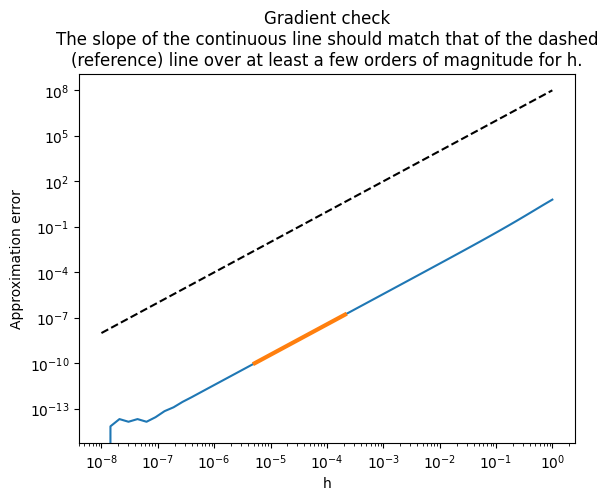

The residual should be close to 0: 7.27599.
If it is far from 0, then the gradient is not in the tangent space.
Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    
   1         +4.9643668774535158e+01    4.99240723e+00    
   2         +4.4770902720403676e+01    5.57385315e+00    
   3         +3.3378660406822355e+01    5.56762508e+00    
   4         +3.1673947573451763e+01    5.42570774e+00    
   5         +2.8717523841235540e+01    2.69648678e+00    
   6         +2.8654376017553698e+01    4.44631215e+00    
   7         +2.8413000547145455e+01    4.05172685e+00    
   8         +2.7648060463937689e+01    2.40236289e+00    
   9         +2.7414621882145049e+01    2.46197379e+00    
  10         +2.6983502717981914e+01    9.78399822e-01    
  11         +2.6842195373823362e+01    1.69619796e+00    
  12         +2.6649797294564284e+01    1.20786528e+00    
  13         +2.6524357237339963e+01    1.357582

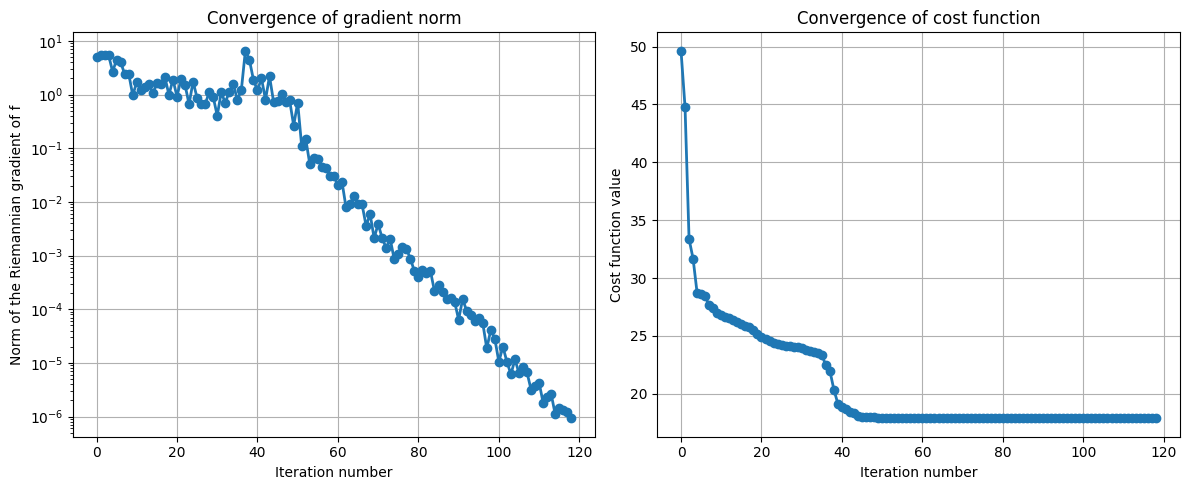

Directional derivative check. The slope of the continuous line should match that of the dashed (reference) line over at least a few orders of magnitude for h.


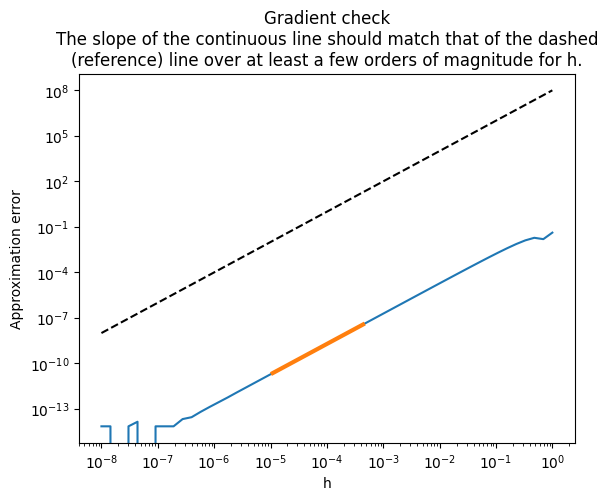

The residual should be close to 0: 7.84471.
If it is far from 0, then the gradient is not in the tangent space.
Hessian check. The slope of the continuous line should match that of the dashed (reference) line over at least a few orders of magnitude for h.


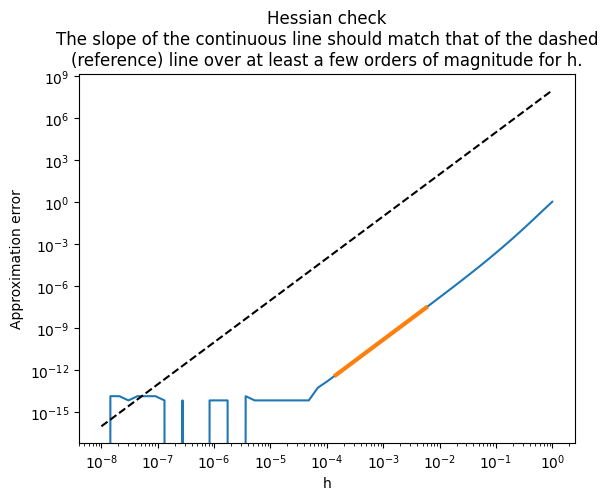

The residual should be 0, or very close. Residual: 6.69482.
If it is far from 0, then the Hessian is not in the tangent space.

The norm of the residual between H[a*d1 + b*d2] and a*H[d1] + b*H[d2] should be very close to 0: 3.42194e-16.
If it is far from 0, then the Hessian is not a linear operator.

The difference <d1, H[d2]> - <H[d1], d2> should be close to zero: 3.59877 - 3.59877 = -1.77636e-15.
If it is far from 0 then the Hessian is not a symmetric operator.
17.886020587850233


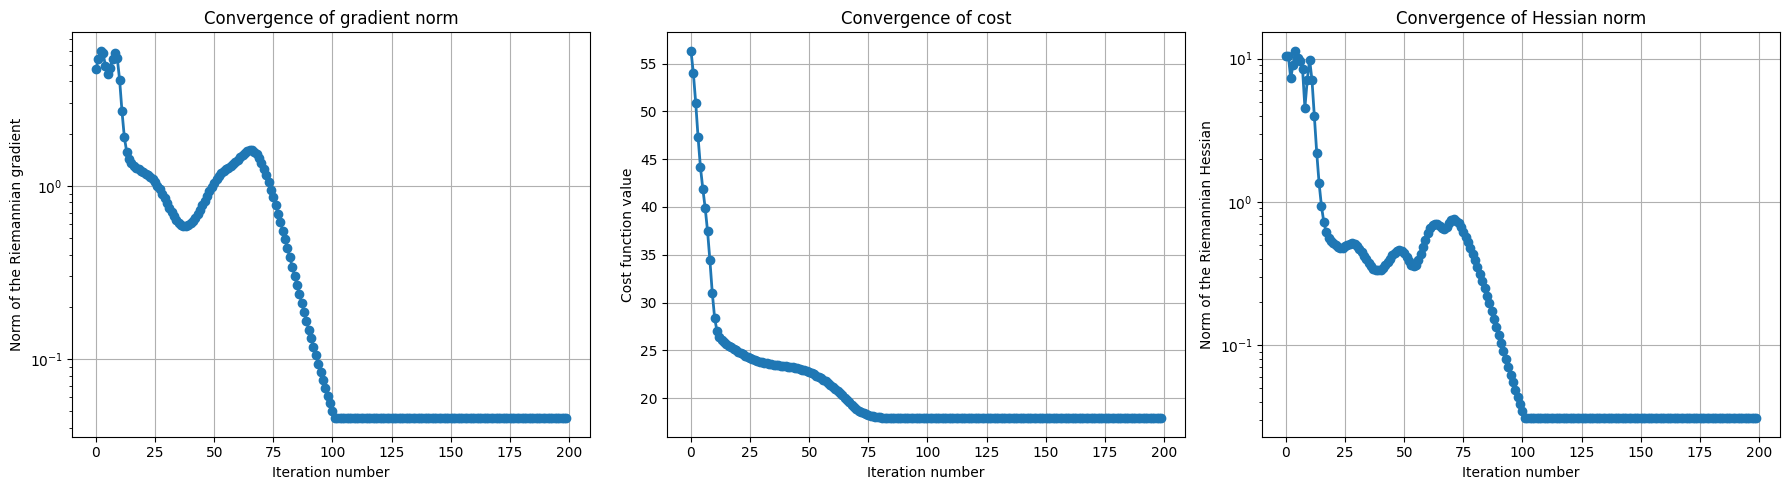

In [ ]:




# Problem setup
d = 3 #warning d<3 because else we cannot define easily the constant C_\kappa
m = 5
anchor_indices = [0]
anchor_values = {0: np.eye(d)}
E = {i: [j for j in range(m) if j != i] for i in range(m)}
H = {}

# Generate synthetic measurements
for i in range(m):
    for j in range(i+1, m):
        R_true_i = special_ortho_group.rvs(d)
        R_true_j = special_ortho_group.rvs(d)
        Z_ij = special_ortho_group.rvs(d)
        H_ij = R_true_i @ Z_ij @ R_true_j.T
        H[(i,j)] = H_ij
        H[(j,i)] = H_ij.T

# Create manifold instance
    manifold = SpecialOrthogonalProductAnchored(d, m, anchor_indices, anchor_values, E, H)

@pymanopt.function.numpy(manifold)
def cost(X):
    total = 0.0
    for i in range(manifold._m):
        for j in manifold._E[i]:  # Avoid double counting
            Zij = X[i].T @ H[(i,j)] @ X[j]
            trace_Z = np.trace(Zij)

            # Compute log probabilities directly
            log_p1 = manifold._kappa1 * (trace_Z - d) - np.log(manifold._c1)
            log_p2 = manifold._kappa2 * (trace_Z - d) - np.log(manifold._c2)

            # Add log weights
            log_p1 += np.log(manifold._q)
            log_p2 += np.log(1 - manifold._q)

            # Log-sum-exp trick
            max_log = max(log_p1, log_p2)
            log_p = max_log + np.log(np.exp(log_p1 - max_log) + np.exp(log_p2 - max_log))


            total += log_p
    return -total  # We're maximizing log-likelihood, but optimizers minimize



@pymanopt.function.numpy(manifold)
def gradf(X):
    grad = np.zeros((manifold._m, manifold._tangent_dim))

    for i in manifold._non_anchors:
        for j in E[i]:
            Zij = X[i].T @ H[(i,j)] @ X[j]
            trace_Z = np.trace(Zij)

            # Compute weights
            p1 = np.exp(manifold._kappa1 * (trace_Z - d) - np.log(manifold._c1))
            p2 = np.exp(manifold._kappa2 * (trace_Z - d) - np.log(manifold._c2))
            p = manifold._q * p1 + (1 - manifold._q) * p2

            alpha_ij = (manifold._q * manifold._kappa1 * p1 +
                       (1 - manifold._q) * manifold._kappa2 * p2) / p

            # Riemannian gradient component
            grad_i= alpha_ij * (H[(i,j)] @ X[j] @ X[i].T -
                                 X[i] @ X[j].T @ H[(i,j)].T) @ X[i]
            grad[i] += manifold._skew(X[i].T.dot(grad_i))

    # Flatten grad into 1D to limit storage
    return -grad


problem=Problem(manifold=manifold, cost=cost, riemannian_gradient=gradf)

check_gradient(problem)

optimizer=optimizers.SteepestDescent(log_verbosity=2)
result=optimizer.run(problem)
grad_norms = optimizer._log["iterations"]["gradient_norm"]
cost_values = optimizer._log["iterations"]["cost"]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.semilogy(grad_norms, '-o', linewidth=2)
plt.xlabel("Iteration number")
plt.ylabel("Norm of the Riemannian gradient of f")
plt.title("Convergence of gradient norm")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(cost_values, '-o', linewidth=2)
plt.xlabel("Iteration number")
plt.ylabel("Cost function value")
plt.title("Convergence of cost function")
plt.grid(True)

plt.tight_layout()
plt.show()






@pymanopt.function.numpy(manifold)
def hess(X,U):
    H=np.zeros((manifold._m, manifold._tangent_dim))

    for i in manifold._non_anchors:
        for j in manifold._E[i]:
            Zij = X[i].T @ manifold._H[(i,j)] @ X[j]

            p1 = np.exp(manifold._kappa1 * (np.trace(Zij) - d)) / manifold._c1
            p2 = np.exp(manifold._kappa2 * (np.trace(Zij) - d)) / manifold._c2
            p = manifold._q * p1 + (1 - manifold._q) * p2
            alpha_ij=(manifold._q * manifold._kappa1 * p1 + (1-manifold._q) * manifold._kappa2 * p2)/p
            beta_ij=(manifold._q * manifold._kappa1**2 * p1 + (1-manifold._q) * manifold._kappa2**2 * p2)/p - alpha_ij**2



            H_ij = manifold._H[(i, j)]
            H_ji = manifold._H[(j, i)]
            X_i = X[i]
            X_j = X[j]
            U_i = X_i.dot(manifold._unskew(U[i]))

            U_j = X_j.dot(manifold._unskew(U[j]))

            # First term: beta_ij * (Trace terms) * (H_ij X_j - X_i X_j^T H_ji X_i)

            trace_term = (np.trace((H_ij @ X_j).T @ U_i) + np.trace((H_ij.T @ X_i).T @ U_j))


            matrix_term = H_ij @ X_j - X_i @ X_j.T @ H_ji @ X_i
            first_part = beta_ij * trace_term * matrix_term

            # Second term: alpha_ij * (complicated expression)
            term1 = -0.5 * (X_i @ X_j.T @ H_ji @ U_i +
                            U_i @ X_j.T @ H_ji @ X_i -
                            X_i @ U_i.T @ H_ij @ X_j -
                            H_ij @ X_j @ U_i.T @ X_i)

            term2 = H_ij @ U_j - X_i @ U_j.T @ H_ji @ X_i
            second_part = alpha_ij * (term1 + term2)
            hess_i=first_part+second_part

            H[i]+=manifold._skew((X[i].T).dot(hess_i))
    return(-H)


problem=Problem(manifold=manifold, cost=cost, riemannian_gradient=gradf, riemannian_hessian=hess)


check_gradient(problem)  #Verify gradient correctness

check_hessian(problem)


from numpy.linalg import norm
import matplotlib.pyplot as plt

hess_norms = []

# Custom optimizer loop to store hessian norms
optimizer = optimizers.SteepestDescent(log_verbosity=2)
x = problem.manifold.random_point()

if optimizer._log is None:
    optimizer._log = {}

optimizer._log["iterations"] = {"gradient_norm": [], "cost": []}

for i in range(200):  # Or until convergence
    grad = problem.riemannian_gradient(x)
    hess = problem.riemannian_hessian(x, grad)

    grad_norm = problem.manifold.norm(x, grad)
    cost = problem.cost(x)
    hess_norm = norm(hess)  # Frobenius norm of the Hessian (as a linear operator)

    optimizer._log["iterations"]["gradient_norm"].append(grad_norm)
    optimizer._log["iterations"]["cost"].append(cost)
    hess_norms.append(hess_norm)

    # Gradient descent step
    step = problem.manifold.retraction(x, -0.1 * grad)
    if i>100:
        step = problem.manifold.retraction(x, -0.1/np.exp(i) * grad)  # Fixed step size or use line search
    x = step
print(problem.cost(x))
# Plotting all
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.semilogy(optimizer._log["iterations"]["gradient_norm"], '-o', linewidth=2)
plt.xlabel("Iteration number")
plt.ylabel("Norm of the Riemannian gradient")
plt.title("Convergence of gradient norm")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(optimizer._log["iterations"]["cost"], '-o', linewidth=2)
plt.xlabel("Iteration number")
plt.ylabel("Cost function value")
plt.title("Convergence of cost")
plt.grid(True)

plt.subplot(1, 3, 3)
plt.semilogy(hess_norms, '-o', linewidth=2)
plt.xlabel("Iteration number")
plt.ylabel("Norm of the Riemannian Hessian")
plt.title("Convergence of Hessian norm")
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
from scipy.io import loadmat
import numpy as np


def matlab_to_python(x):
    """Converts Matlab scalars, vectors or matrices into Python format."""
    if isinstance(x, np.ndarray):
        if x.size == 1:
            return x.item()
        else:
            return x
    return x

def matstruct_to_dict(matobj):
    """Converts recursively a MATLAB struct into Python dictionary"""
    result = {}
    if not hasattr(matobj, '_fieldnames'):
        return matobj
    for field in matobj._fieldnames:
        val = getattr(matobj, field)
        if isinstance(val, np.ndarray) and val.dtype.names:
            result[field] = [matstruct_to_dict(v) for v in val]
        elif hasattr(val, '_fieldnames'):
            result[field] = matstruct_to_dict(val)
        else:
            result[field] = matlab_to_python(val)
    return result

def parse_matlab_data(raw_data):
    """
    Takes a dictionary from scipy.io.loadmat and returns the converted variables.

    Args:
        raw_data (dict): Result from loadmat()

    Returns:
        dict: Python dictionary with the converted variables + struct 'problem' if present
    """
    data = {}
    keys = ['A', 'ERp', 'H', 'I', 'J', 'kappa1', 'kappa2', 'm', 'M', 'n', 'N', 'p', 'Ra', 'Rtrue', 'Z']

    for key in keys:
        if key in raw_data:
            data[key] = matlab_to_python(raw_data[key])
        else:
            print(f" Variable {key} not found in the .mat file.")

    for key in ['I', 'J', 'A']:
        if key in data:
            data[key] = np.atleast_1d(np.squeeze(data[key])).astype(int) - 1

    if 'Ra' in data:
        Ra = data['Ra']
        if Ra.ndim == 2: # if it is (dxd) reshape as dxdx1
            d = Ra.shape[0]
            Ra = Ra[:, :, np.newaxis]
            data['Ra'] = Ra

    # Deal with the structure 'problem'
    if 'problem' in raw_data:
        try:
            data['problem'] = matstruct_to_dict(raw_data['problem'])
        except Exception as e:
            print(f" Error during the conversion of the structure 'problem': {e}")

    return data
mat_path = '/content/drive/MyDrive/Colab Notebooks/optimization on manifold/problem_instance.mat'

raw_data = loadmat(mat_path, struct_as_record=False, squeeze_me=True)
#raw_data = loadmat('problem_instance.mat', struct_as_record=False, squeeze_me=True)
data = parse_matlab_data(raw_data)

In [ ]:
import numpy as np
from scipy.sparse.linalg import eigsh
from scipy.io import loadmat
from collections import defaultdict

In [ ]:
from scipy.sparse.linalg import eigsh

def solve_relaxation(W1, D1, d):
    # Compute the generalized eigenvalues and eigenvectors from W1 v = lambda D1 v
    vals, vecs = eigsh(W1, d, D1, which='LA')

    # Reverse order of eigenvalues to have them from largest to smallest, adapt eigenvectors accordingly
    idx = np.argsort(vals)[::-1]
    vals = vals[idx]
    vecs = vecs[:, idx]

    # Normalize columns of Y so that Y^T D1 Y = Tr(D) * I_d
    tr_D1 = np.trace(D1)
    tr_D = tr_D1 / d
    norm_factor = np.sqrt(tr_D)
    Y_normalized = vecs * norm_factor

    # Write Y as (m, d, d) tensor
    m = W1.shape[0] // d
    Y = Y_normalized.reshape((m, d, d))

    # Compute the maximum value
    max_value = tr_D * np.sum(vals)

    return Y, max_value

# Question 23
import numpy as np
from numpy.linalg import svd, det

# Function performing the projection onto SO(d)
def projection_SO(S):
    U, _, Vt = svd(S)
    determinant = det(U @ Vt)
    P = np.eye(U.shape[0])
    P[-1, -1] = np.sign(determinant)
    return U @ P @ Vt

def initial_guess(deg, m, d, E, H, A, Ra):
    # Inputs:
    #    deg: vector of degrees
    #    m: number of rotations to synchronize
    #    d: rotations are in SO(d)
    #    E: dictionary with the edges
    #    H: tensor with the measurements
    #    A: vector of indices of the anchors
    #    Ra: tensor with anchored rotations
    # Output:
    #    X0_hat: tensor with initial guess

    # Create D1 and W1
    W1 = np.zeros((d*m, d*m))
    for i in range(m):
        for j in E.get(i, []):
            if (i, j) in H:
                block_i = slice(i*d, (i+1)*d)
                block_j = slice(j*d, (j+1)*d)
                W1[block_i, block_j] = H[(i, j)]

    D = np.diag(deg)
    D1 = np.kron(D, np.eye(d))

    # Compute Y
    Y, _ = solve_relaxation(W1, D1, d)

    # Construct Xa and Xb (as tensors)
    J = np.eye(d)
    J[(d-1, d-1)] = -1
    Xa = np.zeros((m, d, d))
    Xb = np.zeros((m, d, d))
    for j in range(m):
        Yj = Y[j]
        Xa[j] = projection_SO(Yj)
        Xb[j] = projection_SO(Yj @ J)

    # Construct X tilde
    fXa = cost(Xa)
    fXb = cost(Xb)
    X_tilde = Xa if fXa >= fXb else Xb

    # Anchor alignment
    P = np.zeros((d, d))
    for idx, j in enumerate(A):
        Xj = X_tilde[j]
        P += Xj.T @ Ra[:, :, idx]
    Q = projection_SO(P)

    # Construct initial guess X0_hat
    X0_hat = np.zeros((m, d, d))
    for j in range(m):
        if j in A:
            X0_hat[j] = Ra[:, :, j]
        else:
            X0_hat[j] = X_tilde[j] @ Q

    return X0_hat



In [ ]:
#Question 25
from scipy.linalg import logm
import numpy as np

def compute_mse(X, X_hat, anchors):
    #print(X.shape)
    #print(X_hat.shape)
    #print(len(anchors))
    mse = 0.0
    for i in range(len(X)):
        if i not in anchors:
            log_diff = logm(X[i].T @ X_hat[i])
            mse += np.linalg.norm(log_diff, 'fro') ** 2
    return mse / (len(X) - len(anchors))


<ipython-input-13-32ae156fe6db>:51: RuntimeWarning: divide by zero encountered in log
  log_p2 += np.log(1 - manifold._q)


Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    
   1         +5.8534659028958458e+02    3.50145274e+01    
   2         +5.3726726032823149e+02    6.17647104e+01    
   3         +3.7841375610339651e+02    6.43665855e+01    
   4         +3.4724334284350601e+02    6.58858862e+01    
   5         +3.0015507830576291e+02    9.27233440e+01    
   6         +1.2825716081669003e+02    1.06922928e+02    
   7         +3.6459709565388437e+01    3.42087049e+01    
   8         +2.3252927195357611e+01    4.65382377e+01    
   9         +1.1543323667903330e+01    1.00091922e+01    
  10         +1.1250665281905080e+01    1.39935543e+01    
  11         +1.0411346642841211e+01    6.23095670e+00    
  12         +1.0332750462252354e+01    6.47957172e+00    
  13         +1.0128396913878817e+01    2.13554246e+00    
  14         +1.0104134683417834e+01    2.13714663e+00    
  15         +1.0098278184334927e+01    2.

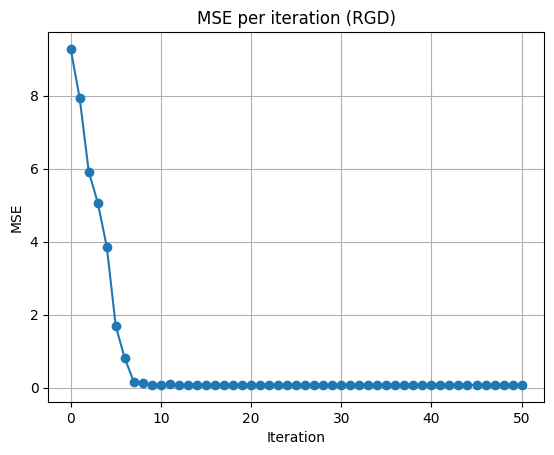

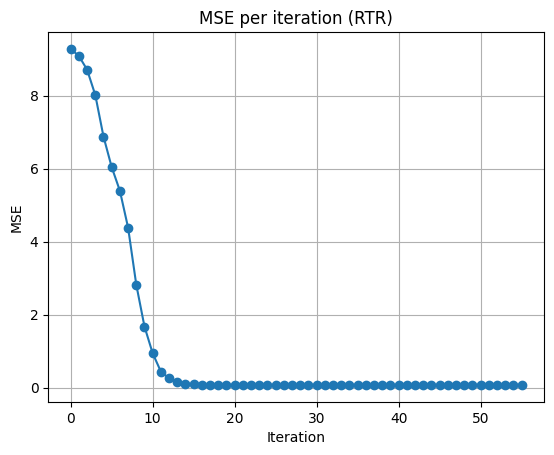

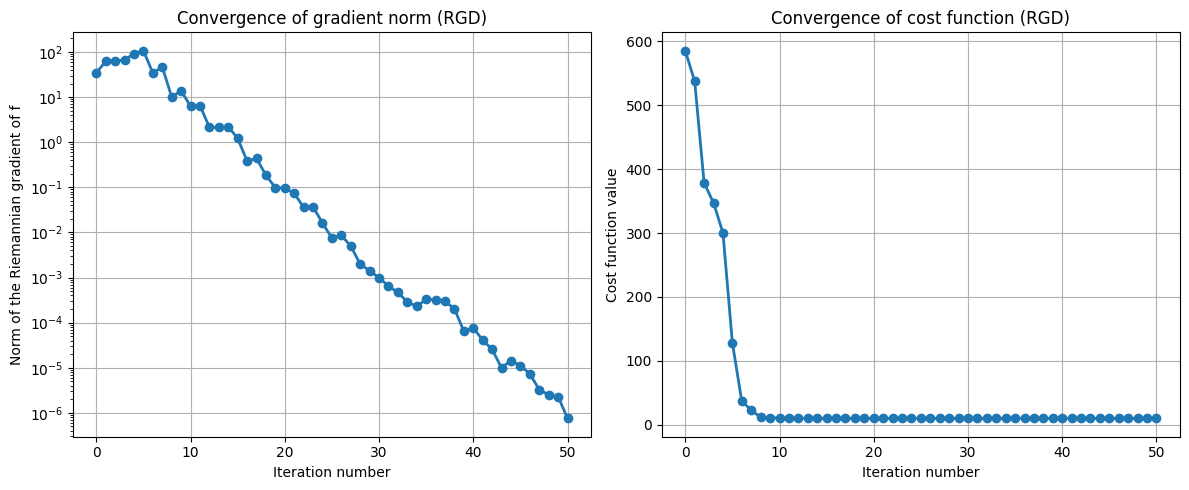

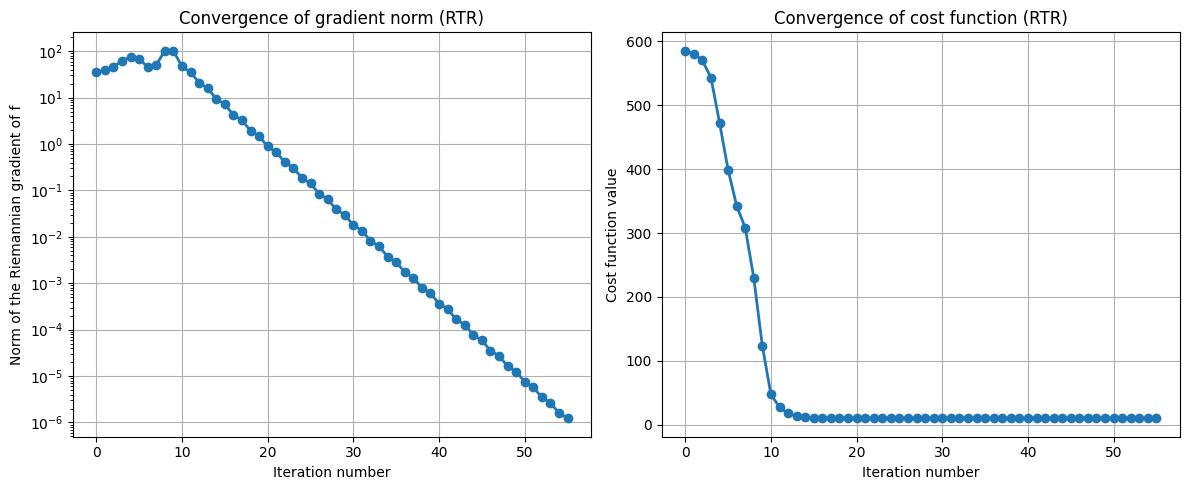

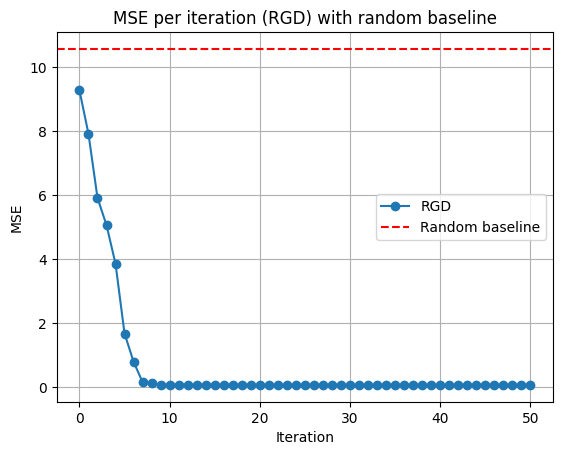

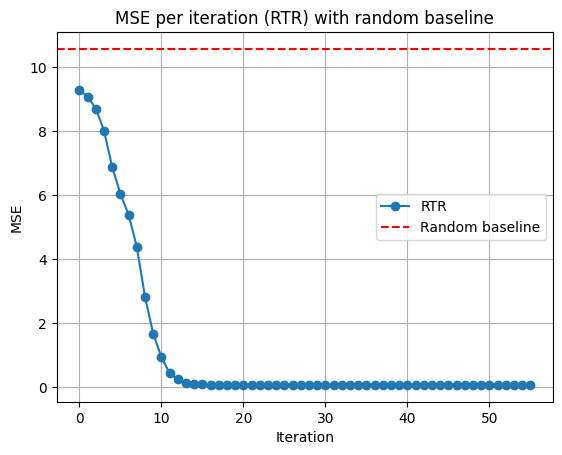

In [ ]:
#Question 26

# (a) Load the data and format it
raw_data = loadmat('/content/drive/MyDrive/Colab Notebooks/optimization on manifold/question_26.mat', struct_as_record=False, squeeze_me=True)
data = parse_matlab_data(raw_data)

# Construct E
E = defaultdict(list)
for i, j in zip(data['I'], data['J']):
    E[i].append(j)
    E[j].append(i)
E = dict(E)
# Construct H
H = {}
for idx, (i, j) in enumerate(zip(data['I'], data['J'])):
    H[(i, j)] = data['H'][:, :, idx]
    H[(j, i)] = data['H'][:, :, idx].T
# Extract useful variables
deg = data['problem']['d']
m = data['N']
d = data['n']
A = data['A']
Ra = data['Ra']
# Construct manifold with the values from data
anchors = list(data['A'])
X_true = np.moveaxis(data['Rtrue'], -1, 0)
X_anchors = np.moveaxis(data['Ra'], -1, 0)
manifold = SpecialOrthogonalProductAnchored(data['n'], data['N'],anchors,X_anchors, E, H)

manifold._kappa1 = float(data['kappa1'][0])
manifold._kappa2 = float(data['kappa2'][0])
manifold._q = float(data['p'][0])



# Recall the cost, grad and hess functions
@pymanopt.function.numpy(manifold)
def cost(X):
    total = 0.0
    for i in range(manifold._m):
        for j in manifold._E[i]:  # Avoid double counting
            Zij = X[i].T @ manifold._H[(i, j)] @ X[j]
            trace_Z = np.trace(Zij)

            # Compute log probabilities directly
            log_p1 = manifold._kappa1 * (trace_Z - manifold._d) - np.log(manifold._c1)
            log_p2 = manifold._kappa2 * (trace_Z - manifold._d) - np.log(manifold._c2)

            # Add log weights
            log_p1 += np.log(manifold._q)
            log_p2 += np.log(1 - manifold._q)

            # Log-sum-exp trick
            max_log = np.maximum(log_p1, log_p2)
            log_p = max_log + np.log(np.exp(log_p1 - max_log) + np.exp(log_p2 - max_log))


            total += log_p
    return -total  # We're maximizing log-likelihood, but optimizers minimize



@pymanopt.function.numpy(manifold)
def gradf(X):
    grad = np.zeros((manifold._m, manifold._tangent_dim))

    for i in manifold._non_anchors:
        for j in manifold._E[i]:
            Zij = X[i].T @ manifold._H[(i,j)] @ X[j]
            trace_Z = np.trace(Zij)

            # Compute weights
            p1 = np.exp(manifold._kappa1 * (trace_Z - manifold._d) - np.log(manifold._c1))
            p2 = np.exp(manifold._kappa2 * (trace_Z - manifold._d) - np.log(manifold._c2))
            p = manifold._q * p1 + (1 - manifold._q) * p2

            alpha_ij = (manifold._q * manifold._kappa1 * p1 +
                        (1 - manifold._q) * manifold._kappa2 * p2) / p

            # Riemannian gradient component
            grad_i= alpha_ij * (manifold._H[(i,j)] @ X[j] @ X[i].T -
                                    X[i] @ X[j].T @ manifold._H[(i,j)].T) @ X[i]
            grad[i] += manifold._skew(X[i].T.dot(grad_i))


    # Flatten grad into 1D to limit storage
    return -grad

@pymanopt.function.numpy(manifold)
def hess(X,U):
    H=np.zeros((manifold._m, manifold._tangent_dim))
    #H=np.zeros((manifold._m, manifold._tangent_dim, manifold._tangent_dim))
    for i in manifold._non_anchors:
        for j in manifold._E[i]:
            Zij = X[i].T @ manifold._H[(i,j)] @ X[j]

            p1 = np.exp(manifold._kappa1 * (np.trace(Zij) - d)) / manifold._c1
            p2 = np.exp(manifold._kappa2 * (np.trace(Zij) - d)) / manifold._c2
            p = manifold._q * p1 + (1 - manifold._q) * p2
            alpha_ij=(manifold._q * manifold._kappa1 * p1 + (1-manifold._q) * manifold._kappa2 * p2)/p
            beta_ij=(manifold._q * manifold._kappa1**2 * p1 + (1-manifold._q) * manifold._kappa2**2 * p2)/p - alpha_ij**2



            H_ij = manifold._H[(i, j)]
            H_ji = manifold._H[(j, i)]
            X_i = X[i]
            X_j = X[j]
            U_i = X_i.dot(manifold._unskew(U[i]))

            U_j = X_j.dot(manifold._unskew(U[j]))

            # First term: beta_ij * (Trace terms) * (H_ij X_j - X_i X_j^T H_ji X_i)

            trace_term = (np.trace((H_ij @ X_j).T @ U_i) + np.trace((H_ij.T @ X_i).T @ U_j))


            matrix_term = H_ij @ X_j - X_i @ X_j.T @ H_ji @ X_i
            first_part = beta_ij * trace_term * matrix_term

            # Second term: alpha_ij * (complicated expression)
            term1 = -0.5 * (X_i @ X_j.T @ H_ji @ U_i +
                            U_i @ X_j.T @ H_ji @ X_i -
                            X_i @ U_i.T @ H_ij @ X_j -
                            H_ij @ X_j @ U_i.T @ X_i)

            term2 = H_ij @ U_j - X_i @ U_j.T @ H_ji @ X_i
            second_part = alpha_ij * (term1 + term2)
            hess_i=first_part+second_part

            H[i]+=manifold._skew((X[i].T).dot(hess_i))
            #H[i]+=hess_i
    return(-H)



# Define the problem
problem_26=Problem(manifold=manifold, cost=cost, riemannian_gradient=gradf, riemannian_hessian=hess)

# Solve the problem first with random initialization and then with spectral initialization
np.random.seed(2)
X0 = initial_guess(deg, m, d, E, H, A, Ra)

#check_gradient(problem_26)
#check_hessian(problem_26)

optimizer_rgd=optimizers.SteepestDescent(log_verbosity=2)
#result_rgd=optimizer_rgd.run(problem_26) # random initialization
result_rgd=optimizer_rgd.run(problem_26, initial_point=X0) # spectral initialization

optimizer_rtr = LoggedTrustRegions(log_verbosity=2)
#result_rtr = optimizer_rtr.run(problem_26,mininner=1, maxinner=1000) # random initialization
result_rtr = optimizer_rtr.run(problem_26,mininner=1, maxinner=1000, initial_point=X0) # spectral initialization

np.random.seed(2)
grad_norms_rgd = optimizer_rgd._log["iterations"]["gradient_norm"]
grad_norms_rtr = optimizer_rtr._log["iterations"]["gradient_norm"]

cost_values_rgd = optimizer_rgd._log["iterations"]["cost"]
cost_values_rtr = optimizer_rtr._log["iterations"]["cost"]

points_rgd = optimizer_rgd._log["iterations"]["point"]
points_rtr = optimizer_rtr._log["iterations"]["point"]

#print(optimizer_rgd._log)

mses_rgd = [compute_mse(X_true, X_hat, anchors) for X_hat in points_rgd]
mses_rtr = [compute_mse(X_true, X_hat, anchors) for X_hat in points_rtr]

# Plot MSEs
plt.plot(mses_rgd, '-o')
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("MSE per iteration (RGD)")
plt.grid(True)
plt.show()

plt.plot(mses_rtr, '-o')
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("MSE per iteration (RTR)")
plt.grid(True)
plt.show()


# Plot the gradient norms and the cost function values
# For RGD
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.semilogy(grad_norms_rgd, '-o', linewidth=2)
plt.xlabel("Iteration number")
plt.ylabel("Norm of the Riemannian gradient of f")
plt.title("Convergence of gradient norm (RGD)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(cost_values_rgd, '-o', linewidth=2)
plt.xlabel("Iteration number")
plt.ylabel("Cost function value")
plt.title("Convergence of cost function (RGD)")
plt.grid(True)

plt.tight_layout()
plt.show()

# For RTR
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.semilogy(grad_norms_rtr, '-o', linewidth=2)
plt.xlabel("Iteration number")
plt.ylabel("Norm of the Riemannian gradient of f")
plt.title("Convergence of gradient norm (RTR)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(cost_values_rtr, '-o', linewidth=2)
plt.xlabel("Iteration number")
plt.ylabel("Cost function value")
plt.title("Convergence of cost function (RTR)")
plt.grid(True)

plt.tight_layout()
plt.show()


# Question 26 part (i)
# Plot of the MSE together with the expected MSE of a random estimator for d=3
mse_threshold = 2 * np.pi**2 / 3 + 4

plt.plot(mses_rgd, '-o', label='RGD')
plt.axhline(mse_threshold, color='r', linestyle='--', label='Random baseline')
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("MSE per iteration (RGD) with random baseline")
plt.legend()
plt.grid(True)
plt.show()

plt.plot(mses_rtr, '-o', label='RTR')
plt.axhline(mse_threshold, color='r', linestyle='--', label='Random baseline')
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("MSE per iteration (RTR) with random baseline")
plt.legend()
plt.grid(True)
plt.show()

Directional derivative check. The slope of the continuous line should match that of the dashed (reference) line over at least a few orders of magnitude for h.


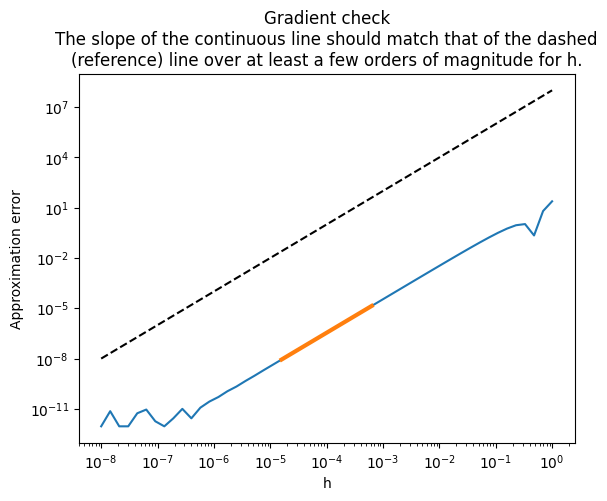

The residual should be close to 0: 47.3421.
If it is far from 0, then the gradient is not in the tangent space.
Hessian check. The slope of the continuous line should match that of the dashed (reference) line over at least a few orders of magnitude for h.


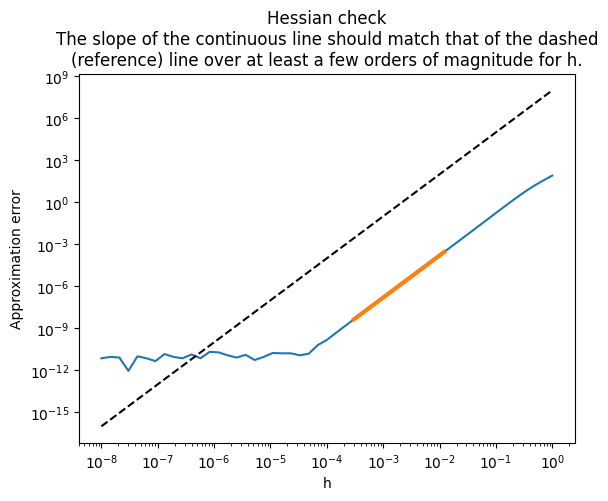

The residual should be 0, or very close. Residual: 123.218.
If it is far from 0, then the Hessian is not in the tangent space.

The norm of the residual between H[a*d1 + b*d2] and a*H[d1] + b*H[d2] should be very close to 0: 5.99143e-14.
If it is far from 0, then the Hessian is not a linear operator.

The difference <d1, H[d2]> - <H[d1], d2> should be close to zero: -48.3555 - -48.3555 = -2.84217e-14.
If it is far from 0 then the Hessian is not a symmetric operator.
Optimizing...
Iteration    Cost                       Gradient norm     
---------    -----------------------    --------------    
   1         +5.1260841922241088e+03    6.92652005e+01    
   2         +5.0560642686996498e+03    7.27307442e+01    
   3         +4.9111747275762218e+03    6.76465551e+01    
   4         +4.8433890043495476e+03    6.43130192e+01    
   5         +4.8059764089603013e+03    7.70838427e+01    
   6         +4.7699180435618900e+03    6.75578033e+01    
   7         +4.7676226959677706e+03    9.6

KeyboardInterrupt: 

In [ ]:
# Question 27
# (a) Load the data and format it
raw_data = loadmat('/content/drive/MyDrive/Colab Notebooks/optimization on manifold/question_27.mat', struct_as_record=False, squeeze_me=True)
data = parse_matlab_data(raw_data)

# Construct E
E = defaultdict(list)
for i, j in zip(data['I'], data['J']):
    E[i].append(j)
    E[j].append(i)
E = dict(E)
# Construct H
H = {}
for idx, (i, j) in enumerate(zip(data['I'], data['J'])):
    H[(i, j)] = data['H'][:, :, idx]
    H[(j, i)] = data['H'][:, :, idx].T
# Extract useful variables
deg = data['problem']['d']
m = data['N']
d = data['n']
A = data['A']
Ra = data['Ra']
# Construct manifold with the values from data
anchors = list(data['A'])
X_true = np.moveaxis(data['Rtrue'], -1, 0)
X_anchors = np.moveaxis(data['Ra'], -1, 0)
manifold = SpecialOrthogonalProductAnchored(data['n'], data['N'],anchors,X_anchors, E, H)

manifold._kappa1 = float(data['kappa1'][0])
manifold._kappa2 = float(data['kappa2'][0])
manifold._q = float(data['p'][0])



# Recall the cost, grad and hess functions
@pymanopt.function.numpy(manifold)
def cost(X):
    total = 0.0
    for i in range(manifold._m):
        for j in manifold._E[i]:  # Avoid double counting
            Zij = X[i].T @ manifold._H[(i, j)] @ X[j]
            trace_Z = np.trace(Zij)

            # Compute log probabilities directly
            log_p1 = manifold._kappa1 * (trace_Z - manifold._d) - np.log(manifold._c1)
            log_p2 = manifold._kappa2 * (trace_Z - manifold._d) - np.log(manifold._c2)

            # Add log weights
            log_p1 += np.log(manifold._q)
            log_p2 += np.log(1 - manifold._q)

            # Log-sum-exp trick
            max_log = np.maximum(log_p1, log_p2)
            log_p = max_log + np.log(np.exp(log_p1 - max_log) + np.exp(log_p2 - max_log))


            total += log_p
    return -total  # We're maximizing log-likelihood, but optimizers minimize



@pymanopt.function.numpy(manifold)
def gradf(X):
    grad = np.zeros((manifold._m, manifold._tangent_dim))

    for i in manifold._non_anchors:
        for j in manifold._E[i]:
            Zij = X[i].T @ manifold._H[(i,j)] @ X[j]
            trace_Z = np.trace(Zij)

            # Compute weights
            p1 = np.exp(manifold._kappa1 * (trace_Z - manifold._d) - np.log(manifold._c1))
            p2 = np.exp(manifold._kappa2 * (trace_Z - manifold._d) - np.log(manifold._c2))
            p = manifold._q * p1 + (1 - manifold._q) * p2

            alpha_ij = (manifold._q * manifold._kappa1 * p1 +
                        (1 - manifold._q) * manifold._kappa2 * p2) / p

            # Riemannian gradient component
            grad_i= alpha_ij * (manifold._H[(i,j)] @ X[j] @ X[i].T -
                                    X[i] @ X[j].T @ manifold._H[(i,j)].T) @ X[i]
            grad[i] += manifold._skew(X[i].T.dot(grad_i))


    # Flatten grad into 1D to limit storage
    return -grad

@pymanopt.function.numpy(manifold)
def hess(X,U):
    H=np.zeros((manifold._m, manifold._tangent_dim))
    #H=np.zeros((manifold._m, manifold._tangent_dim, manifold._tangent_dim))
    for i in manifold._non_anchors:
        for j in manifold._E[i]:
            Zij = X[i].T @ manifold._H[(i,j)] @ X[j]

            p1 = np.exp(manifold._kappa1 * (np.trace(Zij) - d)) / manifold._c1
            p2 = np.exp(manifold._kappa2 * (np.trace(Zij) - d)) / manifold._c2
            p = manifold._q * p1 + (1 - manifold._q) * p2
            alpha_ij=(manifold._q * manifold._kappa1 * p1 + (1-manifold._q) * manifold._kappa2 * p2)/p
            beta_ij=(manifold._q * manifold._kappa1**2 * p1 + (1-manifold._q) * manifold._kappa2**2 * p2)/p - alpha_ij**2



            H_ij = manifold._H[(i, j)]
            H_ji = manifold._H[(j, i)]
            X_i = X[i]
            X_j = X[j]
            U_i = X_i.dot(manifold._unskew(U[i]))

            U_j = X_j.dot(manifold._unskew(U[j]))

            # First term: beta_ij * (Trace terms) * (H_ij X_j - X_i X_j^T H_ji X_i)

            trace_term = (np.trace((H_ij @ X_j).T @ U_i) + np.trace((H_ij.T @ X_i).T @ U_j))


            matrix_term = H_ij @ X_j - X_i @ X_j.T @ H_ji @ X_i
            first_part = beta_ij * trace_term * matrix_term

            # Second term: alpha_ij * (complicated expression)
            term1 = -0.5 * (X_i @ X_j.T @ H_ji @ U_i +
                            U_i @ X_j.T @ H_ji @ X_i -
                            X_i @ U_i.T @ H_ij @ X_j -
                            H_ij @ X_j @ U_i.T @ X_i)

            term2 = H_ij @ U_j - X_i @ U_j.T @ H_ji @ X_i
            second_part = alpha_ij * (term1 + term2)
            hess_i=first_part+second_part

            H[i]+=manifold._skew((X[i].T).dot(hess_i))
            #H[i]+=hess_i
    return(-H)



# Define the problem
problem_27=Problem(manifold=manifold, cost=cost, riemannian_gradient=gradf, riemannian_hessian=hess)

# Solve the problem first with random initialization and then with spectral initialization
np.random.seed(2)
X0 = initial_guess(deg, m, d, E, H, A, Ra)

check_gradient(problem_27)
check_hessian(problem_27)

optimizer_rgd=optimizers.SteepestDescent(log_verbosity=2)
#result_rgd=optimizer_rgd.run(problem_27) # random initialization
result_rgd=optimizer_rgd.run(problem_27, initial_point=X0) # spectral initialization

optimizer_rtr = LoggedTrustRegions(log_verbosity=2)
#result_rtr = optimizer_rtr.run(problem_27,mininner=1, maxinner=1000) # random initialization
result_rtr = optimizer_rtr.run(problem_27,mininner=1, maxinner=1000, initial_point=X0) # spectral initialization

np.random.seed(2)
grad_norms_rgd = optimizer_rgd._log["iterations"]["gradient_norm"]
grad_norms_rtr = optimizer_rtr._log["iterations"]["gradient_norm"]

cost_values_rgd = optimizer_rgd._log["iterations"]["cost"]
cost_values_rtr = optimizer_rtr._log["iterations"]["cost"]

points_rgd = optimizer_rgd._log["iterations"]["point"]
points_rtr = optimizer_rtr._log["iterations"]["point"]

#print(optimizer_rgd._log)

mses_rgd = [compute_mse(X_true, X_hat, anchors) for X_hat in points_rgd]
mses_rtr = [compute_mse(X_true, X_hat, anchors) for X_hat in points_rtr]

# Plot MSEs
plt.plot(mses_rgd, '-o')
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("MSE per iteration (RGD)")
plt.grid(True)
plt.show()

plt.plot(mses_rtr, '-o')
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("MSE per iteration (RTR)")
plt.grid(True)
plt.show()


# Plot the gradient norms and the cost function values
# For RGD
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.semilogy(grad_norms_rgd, '-o', linewidth=2)
plt.xlabel("Iteration number")
plt.ylabel("Norm of the Riemannian gradient of f")
plt.title("Convergence of gradient norm (RGD)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(cost_values_rgd, '-o', linewidth=2)
plt.xlabel("Iteration number")
plt.ylabel("Cost function value")
plt.title("Convergence of cost function (RGD)")
plt.grid(True)

plt.tight_layout()
plt.show()

# For RTR
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.semilogy(grad_norms_rtr, '-o', linewidth=2)
plt.xlabel("Iteration number")
plt.ylabel("Norm of the Riemannian gradient of f")
plt.title("Convergence of gradient norm (RTR)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(cost_values_rtr, '-o', linewidth=2)
plt.xlabel("Iteration number")
plt.ylabel("Cost function value")
plt.title("Convergence of cost function (RTR)")
plt.grid(True)

plt.tight_layout()
plt.show()


Directional derivative check. The slope of the continuous line should match that of the dashed (reference) line over at least a few orders of magnitude for h.


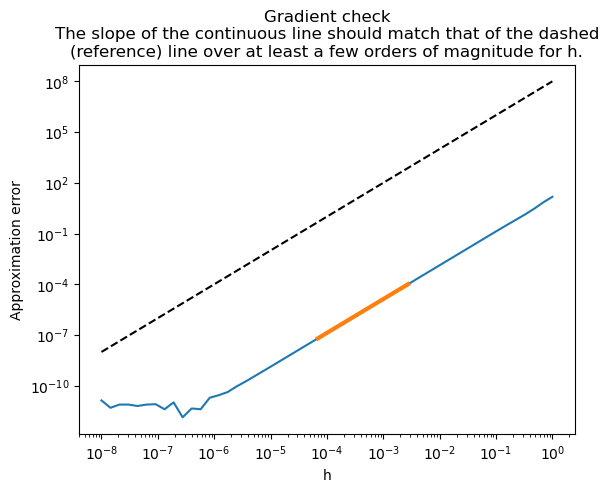

The residual should be close to 0: 50.3456.
If it is far from 0, then the gradient is not in the tangent space.
Hessian check. The slope of the continuous line should match that of the dashed (reference) line over at least a few orders of magnitude for h.


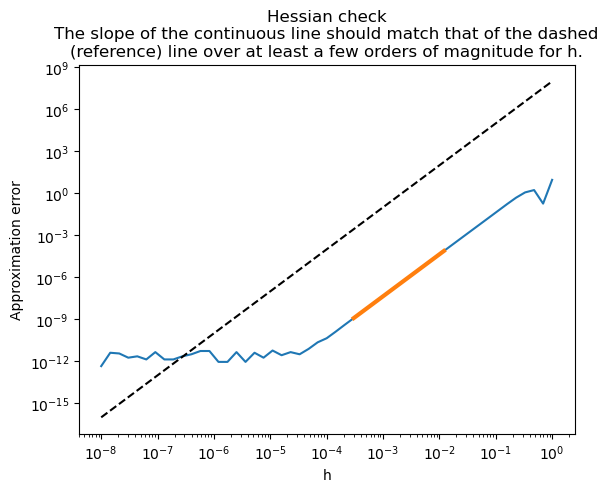

The residual should be 0, or very close. Residual: 97.005.
If it is far from 0, then the Hessian is not in the tangent space.

The norm of the residual between H[a*d1 + b*d2] and a*H[d1] + b*H[d2] should be very close to 0: 5.11597e-14.
If it is far from 0, then the Hessian is not a linear operator.

The difference <d1, H[d2]> - <H[d1], d2> should be close to zero: -20.3385 - -20.3385 = 4.61853e-14.
If it is far from 0 then the Hessian is not a symmetric operator.
Optimizing...
                                            f: +3.766640e+03   |grad|: 7.116575e+01
acc TR+   k:     1     num_inner:     0     f: +3.757695e+03   |grad|: 7.199252e+01   negative curvature
acc TR+   k:     2     num_inner:     0     f: +3.739523e+03   |grad|: 7.347715e+01   negative curvature
acc TR+   k:     3     num_inner:     0     f: +3.702367e+03   |grad|: 7.535049e+01   negative curvature
acc TR+   k:     4     num_inner:     0     f: +3.630837e+03   |grad|: 6.657623e+01   negative curvature
 +++ Detected

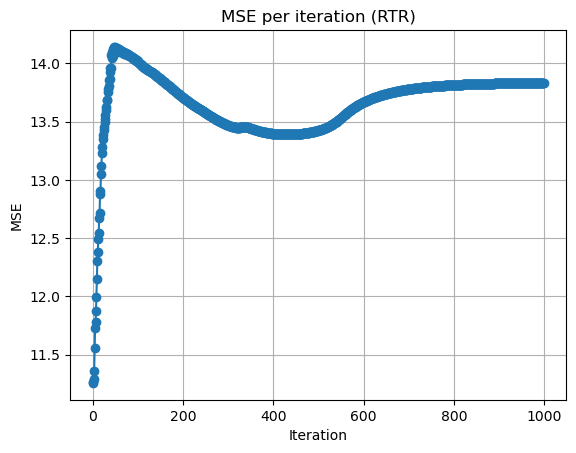

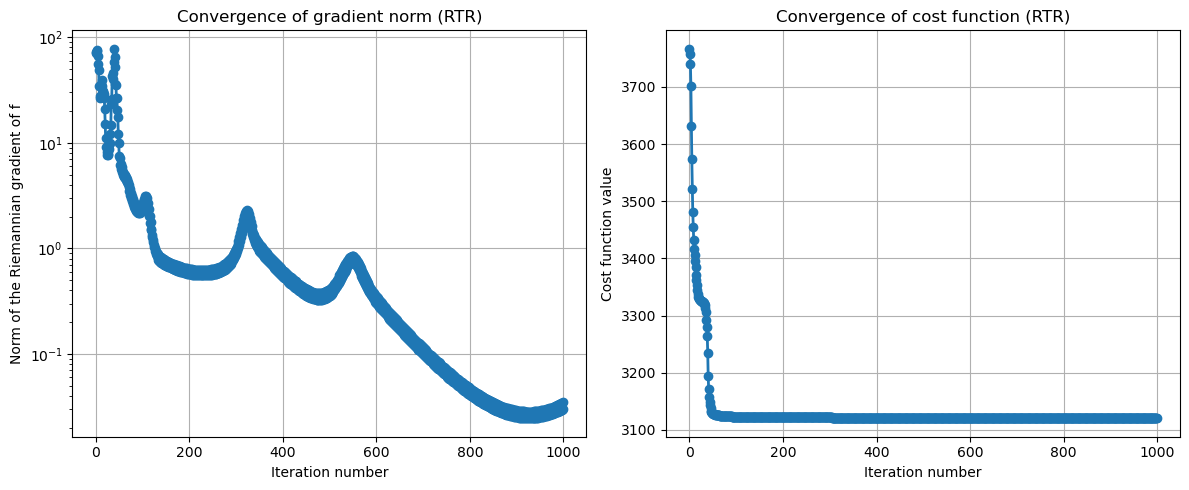

In [ ]:
# Question 28
# (a) Load the data and format it
raw_data = loadmat('/content/drive/MyDrive/Colab Notebooks/optimization on manifold/question_28.mat', struct_as_record=False, squeeze_me=True)
data = parse_matlab_data(raw_data)

# Construct E
E = defaultdict(list)
for i, j in zip(data['I'], data['J']):
    E[i].append(j)
    E[j].append(i)
E = dict(E)
# Construct H
H = {}
for idx, (i, j) in enumerate(zip(data['I'], data['J'])):
    H[(i, j)] = data['H'][:, :, idx]
    H[(j, i)] = data['H'][:, :, idx].T
# Extract useful variables
deg = data['problem']['d']
m = data['N']
d = data['n']
A = data['A']
Ra = data['Ra']
# Construct manifold with the values from data
anchors = list(data['A'])
X_true = np.moveaxis(data['Rtrue'], -1, 0)
X_anchors = np.moveaxis(data['Ra'], -1, 0)
manifold = SpecialOrthogonalProductAnchored(data['n'], data['N'],anchors,X_anchors, E, H)

manifold._kappa1 = float(data['kappa1'][0])
manifold._kappa2 = float(data['kappa2'][0])
manifold._q = float(data['p'][0])



# Recall the cost, grad and hess functions
@pymanopt.function.numpy(manifold)
def cost(X):
    total = 0.0
    for i in range(manifold._m):
        for j in manifold._E[i]:  # Avoid double counting
            Zij = X[i].T @ manifold._H[(i, j)] @ X[j]
            trace_Z = np.trace(Zij)

            # Compute log probabilities directly
            log_p1 = manifold._kappa1 * (trace_Z - manifold._d) - np.log(manifold._c1)
            log_p2 = manifold._kappa2 * (trace_Z - manifold._d) - np.log(manifold._c2)

            # Add log weights
            log_p1 += np.log(manifold._q)
            log_p2 += np.log(1 - manifold._q)

            # Log-sum-exp trick
            max_log = np.maximum(log_p1, log_p2)
            log_p = max_log + np.log(np.exp(log_p1 - max_log) + np.exp(log_p2 - max_log))


            total += log_p
    return -total  # We're maximizing log-likelihood, but optimizers minimize



@pymanopt.function.numpy(manifold)
def gradf(X):
    grad = np.zeros((manifold._m, manifold._tangent_dim))

    for i in manifold._non_anchors:
        for j in manifold._E[i]:
            Zij = X[i].T @ manifold._H[(i,j)] @ X[j]
            trace_Z = np.trace(Zij)

            # Compute weights
            p1 = np.exp(manifold._kappa1 * (trace_Z - manifold._d) - np.log(manifold._c1))
            p2 = np.exp(manifold._kappa2 * (trace_Z - manifold._d) - np.log(manifold._c2))
            p = manifold._q * p1 + (1 - manifold._q) * p2

            alpha_ij = (manifold._q * manifold._kappa1 * p1 +
                        (1 - manifold._q) * manifold._kappa2 * p2) / p

            # Riemannian gradient component
            grad_i= alpha_ij * (manifold._H[(i,j)] @ X[j] @ X[i].T -
                                    X[i] @ X[j].T @ manifold._H[(i,j)].T) @ X[i]
            grad[i] += manifold._skew(X[i].T.dot(grad_i))


    # Flatten grad into 1D to limit storage
    return -grad

@pymanopt.function.numpy(manifold)
def hess(X,U):
    H=np.zeros((manifold._m, manifold._tangent_dim))
    #H=np.zeros((manifold._m, manifold._tangent_dim, manifold._tangent_dim))
    for i in manifold._non_anchors:
        for j in manifold._E[i]:
            Zij = X[i].T @ manifold._H[(i,j)] @ X[j]

            p1 = np.exp(manifold._kappa1 * (np.trace(Zij) - d)) / manifold._c1
            p2 = np.exp(manifold._kappa2 * (np.trace(Zij) - d)) / manifold._c2
            p = manifold._q * p1 + (1 - manifold._q) * p2
            alpha_ij=(manifold._q * manifold._kappa1 * p1 + (1-manifold._q) * manifold._kappa2 * p2)/p
            beta_ij=(manifold._q * manifold._kappa1**2 * p1 + (1-manifold._q) * manifold._kappa2**2 * p2)/p - alpha_ij**2



            H_ij = manifold._H[(i, j)]
            H_ji = manifold._H[(j, i)]
            X_i = X[i]
            X_j = X[j]
            U_i = X_i.dot(manifold._unskew(U[i]))

            U_j = X_j.dot(manifold._unskew(U[j]))

            # First term: beta_ij * (Trace terms) * (H_ij X_j - X_i X_j^T H_ji X_i)

            trace_term = (np.trace((H_ij @ X_j).T @ U_i) + np.trace((H_ij.T @ X_i).T @ U_j))


            matrix_term = H_ij @ X_j - X_i @ X_j.T @ H_ji @ X_i
            first_part = beta_ij * trace_term * matrix_term

            # Second term: alpha_ij * (complicated expression)
            term1 = -0.5 * (X_i @ X_j.T @ H_ji @ U_i +
                            U_i @ X_j.T @ H_ji @ X_i -
                            X_i @ U_i.T @ H_ij @ X_j -
                            H_ij @ X_j @ U_i.T @ X_i)

            term2 = H_ij @ U_j - X_i @ U_j.T @ H_ji @ X_i
            second_part = alpha_ij * (term1 + term2)
            hess_i=first_part+second_part

            H[i]+=manifold._skew((X[i].T).dot(hess_i))
            #H[i]+=hess_i
    return(-H)



# Define the problem
problem_28=Problem(manifold=manifold, cost=cost, riemannian_gradient=gradf, riemannian_hessian=hess)

# Solve the problem first with random initialization and then with spectral initialization
np.random.seed(2)
X0 = initial_guess(deg, m, d, E, H, A, Ra)

check_gradient(problem_28)
check_hessian(problem_28)

optimizer_rtr = LoggedTrustRegions(log_verbosity=2)
result_rtr = optimizer_rtr.run(problem_28,mininner=1, maxinner=1000, initial_point=X0) # spectral initialization

np.random.seed(2)
grad_norms_rtr = optimizer_rtr._log["iterations"]["gradient_norm"]
cost_values_rtr = optimizer_rtr._log["iterations"]["cost"]
points_rtr = optimizer_rtr._log["iterations"]["point"]
mses_rtr = [compute_mse(X_true, X_hat, anchors) for X_hat in points_rtr]

# Plot MSE
plt.plot(mses_rtr, '-o')
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("MSE per iteration (RTR)")
plt.grid(True)
plt.show()


# Plot the gradient norms and the cost function values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.semilogy(grad_norms_rtr, '-o', linewidth=2)
plt.xlabel("Iteration number")
plt.ylabel("Norm of the Riemannian gradient of f")
plt.title("Convergence of gradient norm (RTR)")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(cost_values_rtr, '-o', linewidth=2)
plt.xlabel("Iteration number")
plt.ylabel("Cost function value")
plt.title("Convergence of cost function (RTR)")
plt.grid(True)

plt.tight_layout()
plt.show()

Optimizing...
                                            f: +3.634533e+03   |grad|: 1.043337e+01
acc TR+   k:     1     num_inner:     0     f: +3.633211e+03   |grad|: 1.068346e+01   negative curvature
acc TR+   k:     2     num_inner:     0     f: +3.630554e+03   |grad|: 1.049818e+01   negative curvature
acc TR+   k:     3     num_inner:     0     f: +3.625743e+03   |grad|: 9.242043e+00   exceeded trust region
acc TR+   k:     4     num_inner:     0     f: +3.618232e+03   |grad|: 7.647803e+00   exceeded trust region
 +++ Detected many consecutive TR+ (radius increases).
 +++ Consider increasing options.Delta_bar by an order of magnitude.
 +++ Current values: Delta_bar = 1 and Delta0 = 0.125.
acc TR+   k:     5     num_inner:     0     f: +3.612264e+03   |grad|: 7.995725e+00   exceeded trust region
acc       k:     6     num_inner:     0     f: +3.608549e+03   |grad|: 1.053902e+01   exceeded trust region
acc       k:     7     num_inner:     1     f: +3.606344e+03   |grad|: 1.069869e+

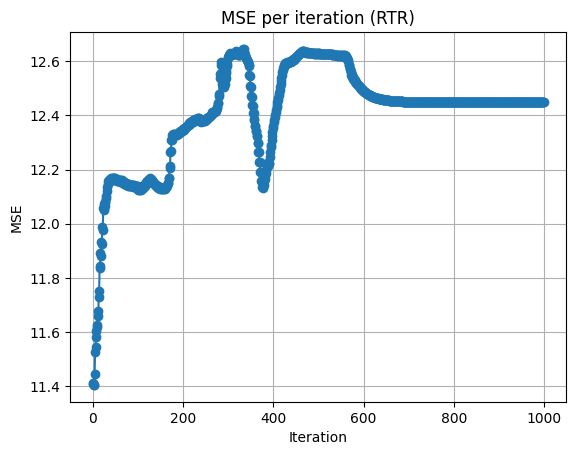

In [ ]:
# Question 29
# First bullet point
# (a) Load the data and format it
raw_data = loadmat('/content/drive/MyDrive/Colab Notebooks/optimization on manifold/question_27_q=0.1.mat', struct_as_record=False, squeeze_me=True)
data = parse_matlab_data(raw_data)

# Construct E
E = defaultdict(list)
for i, j in zip(data['I'], data['J']):
    E[i].append(j)
    E[j].append(i)
E = dict(E)
# Construct H
H = {}
for idx, (i, j) in enumerate(zip(data['I'], data['J'])):
    H[(i, j)] = data['H'][:, :, idx]
    H[(j, i)] = data['H'][:, :, idx].T
# Extract useful variables
deg = data['problem']['d']
m = data['N']
d = data['n']
A = data['A']
Ra = data['Ra']
# Construct manifold with the values from data
anchors = list(data['A'])
X_true = np.moveaxis(data['Rtrue'], -1, 0)
X_anchors = np.moveaxis(data['Ra'], -1, 0)
manifold = SpecialOrthogonalProductAnchored(data['n'], data['N'],anchors,X_anchors, E, H)

manifold._kappa1 = float(data['kappa1'][0])
manifold._kappa2 = float(data['kappa2'][0])
manifold._q = float(data['p'][0])

# Define the problem
problem_29=Problem(manifold=manifold, cost=cost, riemannian_gradient=gradf, riemannian_hessian=hess)

# Solve the problem first with random initialization and then with spectral initialization
np.random.seed(2)
#X0 = initial_guess(deg, m, d, E, H, A, Ra)

#check_gradient(problem_29)
#check_hessian(problem_29)

optimizer_rtr = LoggedTrustRegions(log_verbosity=2)
result_rtr = optimizer_rtr.run(problem_29,mininner=1, maxinner=1000) # random initialization
#result_rtr = optimizer_rtr.run(problem_29,mininner=1, maxinner=1000, initial_point=X0)
np.random.seed(2)
grad_norms_rtr = optimizer_rtr._log["iterations"]["gradient_norm"]
cost_values_rtr = optimizer_rtr._log["iterations"]["cost"]
points_rtr = optimizer_rtr._log["iterations"]["point"]
mses_rtr = [compute_mse(X_true, X_hat, anchors) for X_hat in points_rtr]

# Plot MSE
plt.plot(mses_rtr, '-o')
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("MSE per iteration (RTR)")
plt.grid(True)
plt.show()


In [ ]:
# Question 29
# Second bullet point: varying kappa1

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from collections import defaultdict

# Recall the cost, grad and hess functions
@pymanopt.function.numpy(manifold)
def cost(X):
    total = 0.0
    for i in range(manifold._m):
        for j in manifold._E[i]:  # Avoid double counting
            Zij = X[i].T @ manifold._H[(i, j)] @ X[j]
            trace_Z = np.trace(Zij)

            # Compute log probabilities directly
            log_p1 = manifold._kappa1 * (trace_Z - manifold._d) - np.log(manifold._c1)
            log_p2 = manifold._kappa2 * (trace_Z - manifold._d) - np.log(manifold._c2)

            # Add log weights
            log_p1 += np.log(manifold._q)
            log_p2 += np.log(1 - manifold._q)

            # Log-sum-exp trick
            max_log = np.maximum(log_p1, log_p2)
            log_p = max_log + np.log(np.exp(log_p1 - max_log) + np.exp(log_p2 - max_log))


            total += log_p
    return -total  # We're maximizing log-likelihood, but optimizers minimize



@pymanopt.function.numpy(manifold)
def gradf(X):
    grad = np.zeros((manifold._m, manifold._tangent_dim))

    for i in manifold._non_anchors:
        for j in manifold._E[i]:
            Zij = X[i].T @ manifold._H[(i,j)] @ X[j]
            trace_Z = np.trace(Zij)

            # Compute weights
            p1 = np.exp(manifold._kappa1 * (trace_Z - manifold._d) - np.log(manifold._c1))
            p2 = np.exp(manifold._kappa2 * (trace_Z - manifold._d) - np.log(manifold._c2))
            p = manifold._q * p1 + (1 - manifold._q) * p2

            alpha_ij = (manifold._q * manifold._kappa1 * p1 +
                        (1 - manifold._q) * manifold._kappa2 * p2) / p

            # Riemannian gradient component
            grad_i= alpha_ij * (manifold._H[(i,j)] @ X[j] @ X[i].T -
                                    X[i] @ X[j].T @ manifold._H[(i,j)].T) @ X[i]
            grad[i] += manifold._skew(X[i].T.dot(grad_i))


    # Flatten grad into 1D to limit storage
    return -grad

@pymanopt.function.numpy(manifold)
def hess(X,U):
    H=np.zeros((manifold._m, manifold._tangent_dim))
    #H=np.zeros((manifold._m, manifold._tangent_dim, manifold._tangent_dim))
    for i in manifold._non_anchors:
        for j in manifold._E[i]:
            Zij = X[i].T @ manifold._H[(i,j)] @ X[j]

            p1 = np.exp(manifold._kappa1 * (np.trace(Zij) - d)) / manifold._c1
            p2 = np.exp(manifold._kappa2 * (np.trace(Zij) - d)) / manifold._c2
            p = manifold._q * p1 + (1 - manifold._q) * p2
            alpha_ij=(manifold._q * manifold._kappa1 * p1 + (1-manifold._q) * manifold._kappa2 * p2)/p
            beta_ij=(manifold._q * manifold._kappa1**2 * p1 + (1-manifold._q) * manifold._kappa2**2 * p2)/p - alpha_ij**2



            H_ij = manifold._H[(i, j)]
            H_ji = manifold._H[(j, i)]
            X_i = X[i]
            X_j = X[j]
            U_i = X_i.dot(manifold._unskew(U[i]))

            U_j = X_j.dot(manifold._unskew(U[j]))

            # First term: beta_ij * (Trace terms) * (H_ij X_j - X_i X_j^T H_ji X_i)

            trace_term = (np.trace((H_ij @ X_j).T @ U_i) + np.trace((H_ij.T @ X_i).T @ U_j))


            matrix_term = H_ij @ X_j - X_i @ X_j.T @ H_ji @ X_i
            first_part = beta_ij * trace_term * matrix_term

            # Second term: alpha_ij * (complicated expression)
            term1 = -0.5 * (X_i @ X_j.T @ H_ji @ U_i +
                            U_i @ X_j.T @ H_ji @ X_i -
                            X_i @ U_i.T @ H_ij @ X_j -
                            H_ij @ X_j @ U_i.T @ X_i)

            term2 = H_ij @ U_j - X_i @ U_j.T @ H_ji @ X_i
            second_part = alpha_ij * (term1 + term2)
            hess_i=first_part+second_part

            H[i]+=manifold._skew((X[i].T).dot(hess_i))
            #H[i]+=hess_i
    return(-H)


# Define the list of kappa1 values (assuming files are named consistently)
kappa1_values = [0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
mse_final_random = []
mse_final_spectral = []
cost_final_random = []
cost_final_spectral = []

for kappa1 in kappa1_values:
    filename = '/content/drive/MyDrive/Colab Notebooks/optimization on manifold/question_29_kappa1={kappa1}.mat'
    raw_data = loadmat(filename, struct_as_record=False, squeeze_me=True)
    data = parse_matlab_data(raw_data)

    # Construct E
    E = defaultdict(list)
    for i, j in zip(data['I'], data['J']):
        E[i].append(j)
        E[j].append(i)
    E = dict(E)

    # Construct H
    H = {}
    for idx, (i, j) in enumerate(zip(data['I'], data['J'])):
        H[(i, j)] = data['H'][:, :, idx]
        H[(j, i)] = data['H'][:, :, idx].T

    # Extract problem dimensions and variables
    deg = data['problem']['d']
    m = data['N']
    d = data['n']
    A = data['A']
    Ra = data['Ra']
    anchors = list(data['A'])
    X_true = np.moveaxis(data['Rtrue'], -1, 0)
    X_anchors = np.moveaxis(data['Ra'], -1, 0)

    # Define manifold and problem
    manifold = SpecialOrthogonalProductAnchored(d, m, anchors, X_anchors, E, H)
    manifold._kappa1 = float(data['kappa1'][0])
    manifold._kappa2 = float(data['kappa2'][0])
    manifold._q = float(data['p'][0])

    problem = Problem(manifold=manifold, cost=cost, riemannian_gradient=gradf)

    ### --- RANDOM INITIALIZATION --- ###
    np.random.seed(2)
    optimizer = optimizers.SteepestDescent(log_verbosity=2)
    result_random = optimizer.run(problem)
    points_random = optimizer._log["iterations"]["point"]
    final_X_random = points_random[-1]
    mse_random = compute_mse(X_true, final_X_random, anchors)
    cost_random = cost(final_X_random)
    mse_final_random.append(mse_random)
    cost_final_random.append(cost_random)

    ### --- SPECTRAL INITIALIZATION --- ###
    np.random.seed(2)
    X0 = initial_guess(deg, m, d, E, H, A, Ra)
    optimizer = optimizers.SteepestDescent(log_verbosity=2)
    result_spectral = optimizer.run(problem, initial_point=X0)
    points_spectral = optimizer._log["iterations"]["point"]
    final_X_spectral = points_spectral[-1]
    mse_spectral = compute_mse(X_true, final_X_spectral, anchors)
    cost_spectral = cost(final_X_spectral)
    mse_final_spectral.append(mse_spectral)
    cost_final_spectral.append(cost_spectral)

# --- Plotting the MSE vs kappa1 ---
plt.figure(figsize=(8, 5))
plt.plot(kappa1_values, mse_final_random, '-o', label='Random initialization', linewidth=2)
plt.plot(kappa1_values, mse_final_spectral, '-o', label='Spectral initialization', linewidth=2)
plt.xlabel('κ₁ (concentration of inlier noise)', fontsize=12)
plt.ylabel('Final MSE', fontsize=12)
plt.title('Final MSE vs κ₁ for Different Initializations', fontsize=13)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(kappa1_values, cost_final_random, '-o', label='Random initialization', linewidth=2)
plt.plot(kappa1_values, cost_final_spectral, '-o', label='Spectral initialization', linewidth=2)
plt.xlabel('κ₁ (concentration of inlier noise)', fontsize=12)
plt.ylabel('Final Cost', fontsize=12)
plt.title('Final Cost vs κ₁ for Different Initializations', fontsize=13)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Question 29
# Second bullet point: varying ERp

# Recall the cost, grad and hess functions
@pymanopt.function.numpy(manifold)
def cost(X):
    total = 0.0
    for i in range(manifold._m):
        for j in manifold._E[i]:  # Avoid double counting
            Zij = X[i].T @ manifold._H[(i, j)] @ X[j]
            trace_Z = np.trace(Zij)

            # Compute log probabilities directly
            log_p1 = manifold._kappa1 * (trace_Z - manifold._d) - np.log(manifold._c1)
            log_p2 = manifold._kappa2 * (trace_Z - manifold._d) - np.log(manifold._c2)

            # Add log weights
            log_p1 += np.log(manifold._q)
            log_p2 += np.log(1 - manifold._q)

            # Log-sum-exp trick
            max_log = np.maximum(log_p1, log_p2)
            log_p = max_log + np.log(np.exp(log_p1 - max_log) + np.exp(log_p2 - max_log))


            total += log_p
    return -total  # We're maximizing log-likelihood, but optimizers minimize



@pymanopt.function.numpy(manifold)
def gradf(X):
    grad = np.zeros((manifold._m, manifold._tangent_dim))

    for i in manifold._non_anchors:
        for j in manifold._E[i]:
            Zij = X[i].T @ manifold._H[(i,j)] @ X[j]
            trace_Z = np.trace(Zij)

            # Compute weights
            p1 = np.exp(manifold._kappa1 * (trace_Z - manifold._d) - np.log(manifold._c1))
            p2 = np.exp(manifold._kappa2 * (trace_Z - manifold._d) - np.log(manifold._c2))
            p = manifold._q * p1 + (1 - manifold._q) * p2

            alpha_ij = (manifold._q * manifold._kappa1 * p1 +
                        (1 - manifold._q) * manifold._kappa2 * p2) / p

            # Riemannian gradient component
            grad_i= alpha_ij * (manifold._H[(i,j)] @ X[j] @ X[i].T -
                                    X[i] @ X[j].T @ manifold._H[(i,j)].T) @ X[i]
            grad[i] += manifold._skew(X[i].T.dot(grad_i))


    # Flatten grad into 1D to limit storage
    return -grad

@pymanopt.function.numpy(manifold)
def hess(X,U):
    H=np.zeros((manifold._m, manifold._tangent_dim))
    #H=np.zeros((manifold._m, manifold._tangent_dim, manifold._tangent_dim))
    for i in manifold._non_anchors:
        for j in manifold._E[i]:
            Zij = X[i].T @ manifold._H[(i,j)] @ X[j]

            p1 = np.exp(manifold._kappa1 * (np.trace(Zij) - d)) / manifold._c1
            p2 = np.exp(manifold._kappa2 * (np.trace(Zij) - d)) / manifold._c2
            p = manifold._q * p1 + (1 - manifold._q) * p2
            alpha_ij=(manifold._q * manifold._kappa1 * p1 + (1-manifold._q) * manifold._kappa2 * p2)/p
            beta_ij=(manifold._q * manifold._kappa1**2 * p1 + (1-manifold._q) * manifold._kappa2**2 * p2)/p - alpha_ij**2



            H_ij = manifold._H[(i, j)]
            H_ji = manifold._H[(j, i)]
            X_i = X[i]
            X_j = X[j]
            U_i = X_i.dot(manifold._unskew(U[i]))

            U_j = X_j.dot(manifold._unskew(U[j]))

            # First term: beta_ij * (Trace terms) * (H_ij X_j - X_i X_j^T H_ji X_i)

            trace_term = (np.trace((H_ij @ X_j).T @ U_i) + np.trace((H_ij.T @ X_i).T @ U_j))


            matrix_term = H_ij @ X_j - X_i @ X_j.T @ H_ji @ X_i
            first_part = beta_ij * trace_term * matrix_term

            # Second term: alpha_ij * (complicated expression)
            term1 = -0.5 * (X_i @ X_j.T @ H_ji @ U_i +
                            U_i @ X_j.T @ H_ji @ X_i -
                            X_i @ U_i.T @ H_ij @ X_j -
                            H_ij @ X_j @ U_i.T @ X_i)

            term2 = H_ij @ U_j - X_i @ U_j.T @ H_ji @ X_i
            second_part = alpha_ij * (term1 + term2)
            hess_i=first_part+second_part

            H[i]+=manifold._skew((X[i].T).dot(hess_i))
            #H[i]+=hess_i
    return(-H)


# Define the list of kappa1 values (assuming files are named consistently)
ERp_values = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
mse_final_random = []
mse_final_spectral = []
cost_final_random = []
cost_final_spectral = []

for ERp in ERp_values:
    filename = '/content/drive/MyDrive/Colab Notebooks/optimization on manifold/question_29_ERp={ERp}.mat'
    raw_data = loadmat(filename, struct_as_record=False, squeeze_me=True)
    data = parse_matlab_data(raw_data)

    # Construct E
    E = defaultdict(list)
    for i, j in zip(data['I'], data['J']):
        E[i].append(j)
        E[j].append(i)
    E = dict(E)

    # Construct H
    H = {}
    for idx, (i, j) in enumerate(zip(data['I'], data['J'])):
        H[(i, j)] = data['H'][:, :, idx]
        H[(j, i)] = data['H'][:, :, idx].T

    # Extract problem dimensions and variables
    deg = data['problem']['d']
    m = data['N']
    d = data['n']
    A = data['A']
    Ra = data['Ra']
    anchors = list(data['A'])
    X_true = np.moveaxis(data['Rtrue'], -1, 0)
    X_anchors = np.moveaxis(data['Ra'], -1, 0)

    # Define manifold and problem
    manifold = SpecialOrthogonalProductAnchored(d, m, anchors, X_anchors, E, H)
    manifold._kappa1 = float(data['kappa1'][0])
    manifold._kappa2 = float(data['kappa2'][0])
    manifold._q = float(data['p'][0])

    problem = Problem(manifold=manifold, cost=cost, riemannian_gradient=gradf)

    ### --- RANDOM INITIALIZATION --- ###
    np.random.seed(2)
    optimizer = optimizers.SteepestDescent(log_verbosity=2)
    result_random = optimizer.run(problem)  # No initial_point → random
    points_random = optimizer._log["iterations"]["point"]
    final_X_random = points_random[-1]
    mse_random = compute_mse(X_true, final_X_random, anchors)
    cost_random = cost(final_X_random)
    mse_final_random.append(mse_random)
    cost_final_random.append(cost_random)

    ### --- SPECTRAL INITIALIZATION --- ###
    np.random.seed(2)
    X0 = initial_guess(deg, m, d, E, H, A, Ra)
    optimizer = optimizers.SteepestDescent(log_verbosity=2)
    result_spectral = optimizer.run(problem, initial_point=X0)
    points_spectral = optimizer._log["iterations"]["point"]
    final_X_spectral = points_spectral[-1]
    mse_spectral = compute_mse(X_true, final_X_spectral, anchors)
    cost_spectral = cost(final_X_spectral)
    mse_final_spectral.append(mse_spectral)
    cost_final_spectral.append(cost_spectral)

# --- Plotting the MSE vs ERp ---
plt.figure(figsize=(8, 5))
plt.plot(ERp_values, mse_final_random, '-o', label='Random initialization', linewidth=2)
plt.plot(ERp_values, mse_final_spectral, '-o', label='Spectral initialization', linewidth=2)
plt.xlabel('Edge Density', fontsize=12)
plt.ylabel('Final MSE', fontsize=12)
plt.title('Final MSE vs Edge Density for Different Initializations', fontsize=13)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(ERp_values, cost_final_random, '-o', label='Random initialization', linewidth=2)
plt.plot(ERp_values, cost_final_spectral, '-o', label='Spectral initialization', linewidth=2)
plt.xlabel('Edge Density', fontsize=12)
plt.ylabel('Final Cost', fontsize=12)
plt.title('Final Cost vs Edge Density for Different Initializations', fontsize=13)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()